---
---
# Importación de paquetes
___
___

In [1]:
import os
import pandas as pd                 # Importación de la biblioteca pandas para el manejo de datos contenidos en una base de datos
import paquete_funciones as pq_fcn  # Módulo que contiene las funciones desarrolladas para la limpieza y pre-procesamiento de datos
os.getcwd()                         # Obtención de la Ruta del Notebook

'c:\\Users\\ernesto.molina\\OneDrive - FUNKEN\\Documentos\\FKTrabajo\\Internos\\Curso Data Analyst\\dirty_data'

# **Caso Ejemplo**

## 🔧 Paso 1: Importación de los Datos

In [2]:
nombre_variable, datos = pq_fcn.importar_base_datos(
    nombre_archivo_datos='dirty_cafe_sales.csv',
    indice_etiquetas=0,
    indice_datos=1,
    separador=','
)

Etiquetas contenidas en la base de datos:
Transaction ID 	
Item 	
Quantity 	
Price Per Unit 	
Total Spent 	
Payment Method 	
Location 	
Transaction Date 	

Muestra de los datos extraídos: 
 [['TXN_1961373' 'TXN_4977031' 'TXN_4271903' 'TXN_7034554' 'TXN_3160411']
 ['Coffee' 'Cake' 'Cookie' 'Salad' 'Coffee']
 ['2' '4' '4' '2' '2']
 ['2.0' '3.0' '1.0' '5.0' '2.0']
 ['4.0' '12.0' 'ERROR' '10.0' '4.0']
 ['Credit Card' 'Cash' 'Credit Card' 'UNKNOWN' 'Digital Wallet']
 ['Takeaway' 'In-store' 'In-store' 'UNKNOWN' 'In-store']
 ['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11']]



## ⚙️ Paso 2: Categorización Inferida de los Datos

Resultado del Casteo Inicial de los Datos: 
 [[nan nan nan nan nan]
 [nan nan nan nan nan]
 [ 2.  4.  4.  2.  2.]
 [ 2.  3.  1.  5.  2.]
 [ 4. 12. nan 10.  4.]
 [nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]]

Proporción de Datos Nulos por Variable: 
           Categoria  Porcentaje
0    Transaction ID      100.00
1              Item      100.00
2          Quantity        4.79
3    Price Per Unit        5.33
4       Total Spent        5.02
5    Payment Method      100.00
6          Location      100.00
7  Transaction Date      100.00



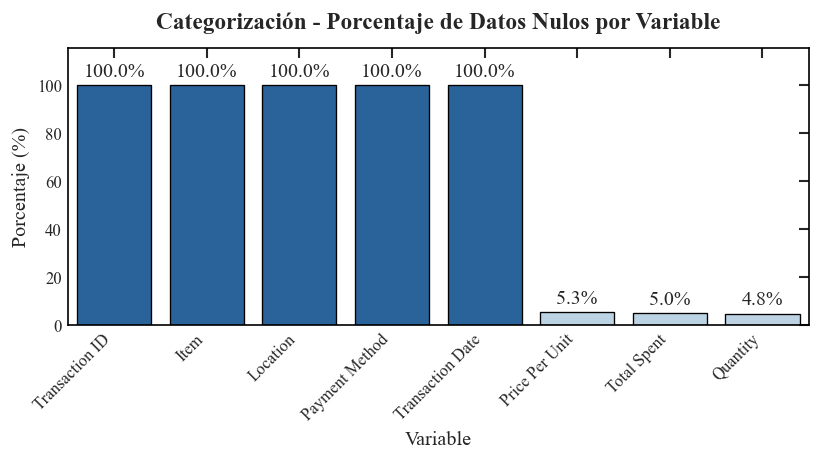

In [3]:
valores_porcentuales = pq_fcn.categorizacion_inicial_datos(datos=datos, etiquetas=nombre_variable)

In [4]:
pd.DataFrame(datos.transpose(), columns=nombre_variable).head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


### 📊 Análisis y Diagnóstico Visual: [Categorización Inicial de los Datos]

A partir de los resultados obtenidos y visualizados en la gráfica anterior durante la etapa de **[Nombre de la etapa, ej: categorización inicial]**, se establecen las siguientes observaciones respecto al comportamiento estructural del dataset:

#### 🔍 Hallazgos por Tipo de Variable

*   **Variables Categóricas / Textuales (100% Conversiones Falladas):**
    Las variables `Transaction ID`, `Item`, `Payment Method`, `Location` y `Transaction Date` presentan un **100 % de conversiones fallidas** durante el proceso de `casteo`. Este comportamiento constituye una fuerte evidencia de que su dominio está conformado por valores de naturaleza categórica o textual.
    *   **Acción/Estado:** Clasificadas preliminarmente como *variables no numéricas*.

*   **Variables Numéricas Limpias (Alta Compatibilidad):**
    Las variables `Price Per Unit`, `Total Spent` y `Quantity` presentan un predominio de conversiones exitosas hacia el tipo `float`, evidenciando una elevada compatibilidad estructural.
    *   **Acción/Estado:** Clasificadas preliminarmente como *variables numéricas/cuantitativas*.

*   **Casos de incompatibilidad:**
    * No se detectaron casos que constituyan una incompatibilidad de la semántica de los datos proveídos en la base de datos y la clasificación preliminar que se ha otorgado

#### 📌 Conclusión General de la Etapa

La estrategia de inferencia basada en porcentajes otorga una primera aproximación estructural automatizada, en el cual se detecta la posibilidad de existencia de 5 variables categóricas y 3 variables de naturaleza numérica. 

Estas observaciones deberán ser complementadas en etapas posteriores de análisis estadístico y evaluación semántica para validar la naturaleza definitiva de cada columna antes de aplicar técnicas de imputación o eliminación.

Por tanto:
* variables no numéricas: `Transaction ID`, `Item`, `Payment Method`, `Location` y `Transaction Date`.
* variables numéricas: `Price Per Unit`, `Total Spent` y `Quantity`

## 🧠 Paso 3: Inferencia en el Tipo de Variables y Conformación del DataFrame

In [5]:
lista_excepciones = None

In [6]:
dic_etiquetas = {
    'Transaction ID' : 'id',
    'Item' : 'producto',
    'Quantity' : 'cantidad',
    'Price Per Unit' : 'precio_por_unidad',
    'Total Spent' : 'total_gastado',
    'Payment Method ' : 'metodo_pago',
    'Location' : 'ubicacion',
    'Transaction Date' : 'fecha',
}

In [7]:
valores = pq_fcn.conformar_base_datos(
    datos=datos,
    porcentajes=valores_porcentuales,
    etiquetas=nombre_variable,
    excepciones=lista_excepciones,
    diccionario_renombrado=dic_etiquetas
)
columnas_numericas = valores['variables']['numericas']
columnas_no_numericas = valores['variables']['no_numericas']
datos_pandas = valores['datos']

Variables clasificadas como numéricas:
- cantidad
- precio_por_unidad
- total_gastado

Variables clasificadas como no numéricas:
- id
- producto
- Payment Method
- ubicacion
- fecha



In [8]:
datos_pandas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10000 non-null  str    
 1   producto           9667 non-null   str    
 2   cantidad           9521 non-null   float64
 3   precio_por_unidad  9467 non-null   float64
 4   total_gastado      9498 non-null   float64
 5   Payment Method     7421 non-null   str    
 6   ubicacion          6735 non-null   str    
 7   fecha              9841 non-null   str    
dtypes: float64(3), str(5)
memory usage: 625.1 KB


## 🔍 Paso 4: Exploración de Variables con Formato no Numérico

In [9]:
datos_pandas[columnas_no_numericas].head()

,id,producto,Payment Method,ubicacion,fecha
0,TXN_1961373,Coffee,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,Digital Wallet,In-store,2023-06-11


In [10]:
pq_fcn.exploracion_inicial_datos_categoricos(datos_pandas, columnas_no_numericas)

Análisis Exploratorio Inicial de Datos No Numéricos
Total de Registros en el Dataset: 10000

------------------------------------------------------------
Análisis de la Variable: id
------------------------------------------------------------
Cantidad de Valores Únicos (Cardinalidad): 10000
Valores Faltantes (NaN): 0 (0.00%)

------------------------------------------------------------
Análisis de la Variable: producto
------------------------------------------------------------
Cantidad de Valores Únicos (Cardinalidad): 10
Valores Faltantes (NaN): 333 (3.33%)

------------------------------------------------------------
Análisis de la Variable: Payment Method
------------------------------------------------------------
Cantidad de Valores Únicos (Cardinalidad): 5
Valores Faltantes (NaN): 2579 (25.79%)

------------------------------------------------------------
Análisis de la Variable: ubicacion
------------------------------------------------------------
Cantidad de Valores Únicos (

In [10]:
datos_pandas[columnas_no_numericas].isnull().sum()

id                   0
producto           333
Payment Method    2579
ubicacion         3265
fecha              159
dtype: int64

In [11]:
datos_pandas[columnas_no_numericas].nunique()/datos_pandas.shape[0]*100

id                100.00
producto            0.10
Payment Method      0.05
ubicacion           0.04
fecha               3.67
dtype: float64

###  ⭐ *Observaciones*

📌 Observaciones generales

* En esta etapa del análisis, todas las variables clasificadas dentro de este grupo se encuentran representadas mediante cadenas de caracteres (`str`).

---

🔄 Tipado de variables

* La variable `fecha_prestamo` corresponde a una variable de naturaleza temporal. En consecuencia, se recomienda convertirla al tipo de dato `datetime`, con el propósito de estandarizar su representación y facilitar el desarrollo de análisis temporales, el cálculo de intervalos y la extracción de componentes como año, mes o día.

* La variable `meses_prestamo`, aunque actualmente se encuentra representada mediante cadenas de caracteres, almacena una magnitud cuantitativa expresada en meses. Por ello, se recomienda transformar su contenido a un formato numérico que represente directamente dicha cantidad, simplificando su tratamiento durante el análisis y las etapas posteriores de modelado.

* Para las variables restantes no se identifican inconsistencias en su representación que justifiquen transformaciones adicionales del tipo de dato durante esta etapa del preprocesamiento.

---

🗂️ Redundancia de información

* Las variables `identificador` y `enlace` no presentan valores faltantes y poseen valores únicos para cada registro del conjunto de datos. Este comportamiento indica que ambas cumplen la función de identificar de manera unívoca cada préstamo, lo que constituye una posible redundancia de información. En consecuencia, se recomienda evaluar la eliminación de una de estas variables con el fin de reducir la dimensionalidad del conjunto de datos sin afectar la información disponible para el análisis.

* Las variables `grado` y `sub_grado` presentan una relación jerárquica en su codificación, ya que la información contenida en `grado` se encuentra parcialmente incorporada en `sub_grado`. Sin embargo, debido a la presencia de valores faltantes en ambas variables, no resulta recomendable eliminar ninguna de ellas en esta etapa. Es posible que una de estas variables sea necesaria para realizar procesos de imputación cruzada sobre la otra, por lo que la evaluación definitiva de su redundancia deberá realizarse una vez concluido el tratamiento de los datos faltantes.

---

## ✏️ Paso 5: Corrección de Formato Inferido

### ❌ Eliminación de Variables con Información Redundates

#### Variable: *enlace*

In [65]:
# eliminación de la variable enlace de la base de datos
if 'enlace' in datos_pandas.columns:
    datos_pandas = datos_pandas.drop('enlace', axis=1)
    columnas_no_numericas.remove('enlace')
datos_pandas[columnas_no_numericas].head()

,identificador,fecha_prestamo,estado_prestamo,meses_prestamo,grado,sub_grado,estado_verificacion,estado
0,48010226,May-15,Current,36 months,C,C3,Verified,CA
1,57693261,NaN,Current,36 months,A,A5,Source Verified,NY
2,59432726,Sep-15,Current,36 months,B,B5,Verified,PA
3,53222800,Jul-15,Current,36 months,A,A5,Not Verified,OH
4,57803010,Aug-15,Current,36 months,NaN,E3,Source Verified,TX


✅ El proceso de eliminación de la variable dentro de la base de datos se realizó de manera satisfactoria

### 🔄 Modificación en el Formato de la Variable

#### Variable: *fecha_prestamo*

In [66]:
# evaluar el formato de datos contenidos en la variable fecha_prestamo
fecha_previa = datos_pandas['fecha_prestamo'].value_counts().reset_index()

In [67]:
fecha_previa

,fecha_prestamo,count
0,Oct-15,1095
1,Jul-15,1061
2,Dec-15,997
3,Nov-15,847
4,Aug-15,846
5,Jan-15,770
6,Apr-15,757
7,May-15,741
8,Jun-15,654
9,Sep-15,643


✅ No es necesario realizar un proceso adicional de estandarización sobre los datos contenidos en esta variable, ya que cada uno de los meses del año se encuentra representado mediante una única etiqueta. En consecuencia, no se observan inconsistencias en la codificación que requieran procesos de normalización o unificación de categorías.

In [68]:
# cambiar formato de datos contenidos en la variable fecha_prestamo
datos_pandas['fecha_prestamo'] = pd.to_datetime(datos_pandas['fecha_prestamo'], errors='coerce')
datos_pandas[columnas_no_numericas].head()

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_18216\2195420090.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datos_pandas['fecha_prestamo'] = pd.to_datetime(datos_pandas['fecha_prestamo'], errors='coerce')


,identificador,fecha_prestamo,estado_prestamo,meses_prestamo,grado,sub_grado,estado_verificacion,estado
0,48010226,1-05-15,Current,36 months,C,C3,Verified,CA
1,57693261,NaT,Current,36 months,A,A5,Source Verified,NY
2,59432726,1-09-15,Current,36 months,B,B5,Verified,PA
3,53222800,1-07-15,Current,36 months,A,A5,Not Verified,OH
4,57803010,1-08-15,Current,36 months,NaN,E3,Source Verified,TX


In [69]:
fecha_actual = datos_pandas['fecha_prestamo'].dt.strftime('%b').value_counts().reset_index()

In [70]:
fecha_previa.merge(
    fecha_actual,
    left_index=True,
    right_index=True,
    how='inner'
)

,fecha_prestamo_x,count_x,fecha_prestamo_y,count_y
0,Oct-15,1095,Oct,1095
1,Jul-15,1061,Jul,1061
2,Dec-15,997,Dec,997
3,Nov-15,847,Nov,847
4,Aug-15,846,Aug,846
5,Jan-15,770,Jan,770
6,Apr-15,757,Apr,757
7,May-15,741,May,741
8,Jun-15,654,Jun,654
9,Sep-15,643,Sep,643


✅ El proceso de transformación se realizó correctamente, ya que no se observaron diferencias en el número de registros contabilizados antes y después de la modificación del formato de los datos contenidos en la variable `fecha_prestamo`.

#### Variable: *meses_prestamo*

In [71]:
# evaluar el formato de datos contenidos en la variable meses_prestamo
meses_previo = datos_pandas['meses_prestamo'].value_counts().reset_index()
meses_previo

,meses_prestamo,count
0,36 months,6281
1,60 months,3219


✅ No es necesario realizar un proceso adicional de estandarización sobre los datos contenidos en esta variable, ya que todos sus valores siguen un formato homogéneo y consistente. En consecuencia, la conversión al tipo de dato correspondiente puede realizarse de manera directa y sin requerir etapas previas de normalización.

In [72]:
# cambiar formato de datos contenidos en la variable meses_prestamo
if 'meses_prestamo' in columnas_no_numericas:
    datos_pandas['meses_prestamo'] = pd.to_numeric(datos_pandas['meses_prestamo'].str.strip().str.split().str[0], errors='coerce')
    columnas_no_numericas.remove('meses_prestamo')
    columnas_numericas.append('meses_prestamo')
datos_pandas[columnas_no_numericas].head()

,identificador,fecha_prestamo,estado_prestamo,grado,sub_grado,estado_verificacion,estado
0,48010226,1-05-15,Current,C,C3,Verified,CA
1,57693261,NaT,Current,A,A5,Source Verified,NY
2,59432726,1-09-15,Current,B,B5,Verified,PA
3,53222800,1-07-15,Current,A,A5,Not Verified,OH
4,57803010,1-08-15,Current,NaN,E3,Source Verified,TX


In [73]:
datos_pandas[columnas_numericas].head()

,solicitud_prestamo_EUR,aceptacion_prestamo_EUR,razon_intereses,pago_mensual_EUR,pago_efectuado_EUR,meses_prestamo
0,35000.0,35000.0,13.33,1184.86,9452.96,36.0
1,30000.0,30000.0,NaN,938.57,4679.70,36.0
2,15000.0,15000.0,NaN,494.86,1969.83,36.0
3,9600.0,9600.0,NaN,300.35,1793.68,36.0
4,8075.0,8075.0,19.19,296.78,1178.51,36.0


In [74]:
meses_actuales = datos_pandas['meses_prestamo'].value_counts().reset_index()

In [75]:
meses_previo.merge(
    meses_actuales,
    left_index=True,
    right_index=True,
    how='inner'
)

,meses_prestamo_x,count_x,meses_prestamo_y,count_y
0,36 months,6281,36.0,6281
1,60 months,3219,60.0,3219


✅ El proceso de transformación se realizó correctamente, ya que no se observaron diferencias en el número de registros contabilizados antes y después de la modificación del formato de los datos contenidos en la variable `meses_prestamo`.

## 🚩 Paso 6: Primer CheckPoint en Formato CSV - Datos Categorizados

In [76]:
datos_pandas.to_csv('checkpoint_01.csv')

## ✨ Paso 7: Análisis de la Calidad de los Datos

###  **Métricas de Completitud / Ausencia de Datos**

Análisis de Completitud: Base de Datos
🔹  Análisis General de la Completitud de la Base de Datos
        - Total de datos faltantes: 11534
        - Total de datos en la base de datos: 130000
        - Proporción de valores faltantes con relación al total: 8.872 %
        - Índice global de completitud 91.128 %



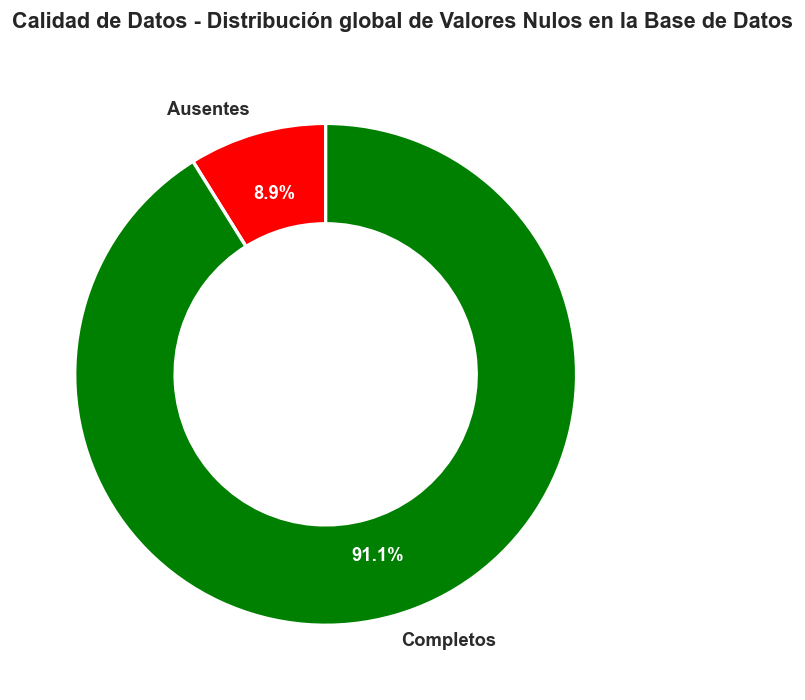


Análisis de Completitud: Comportamiento por Registros
🔹 Formato Tabular de los Resultados Obtenidos: 
   cantidad_nulos  porcentaje
0               1       51.11
1               2       31.96
2               0       16.83
3               3        0.09
4               4        0.01

🔹 Análisis Cuantitativo de la Completitud de la Base de Datos por Registros
    Total de registros con al menos un dato ausente: 8317
    Total de registros: 10000
    Proporción de registros con datos ausentes respecto al total: 83.17 %
    Índice de completitud de los registros (filas limpias): 16.83 %

🔹 Formato Gráfico de los Resultados Obtenidos: 


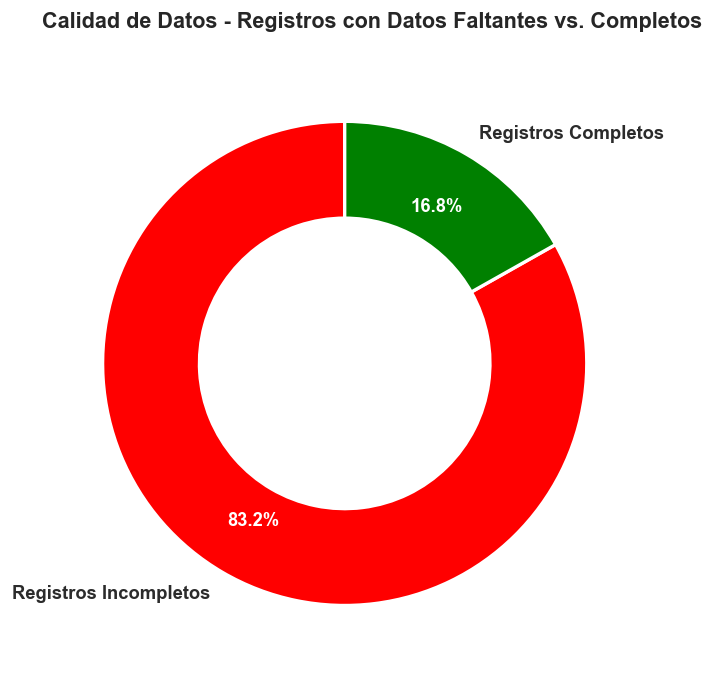


📊 Severidad del Impacto de Datos Faltantes por Registro:



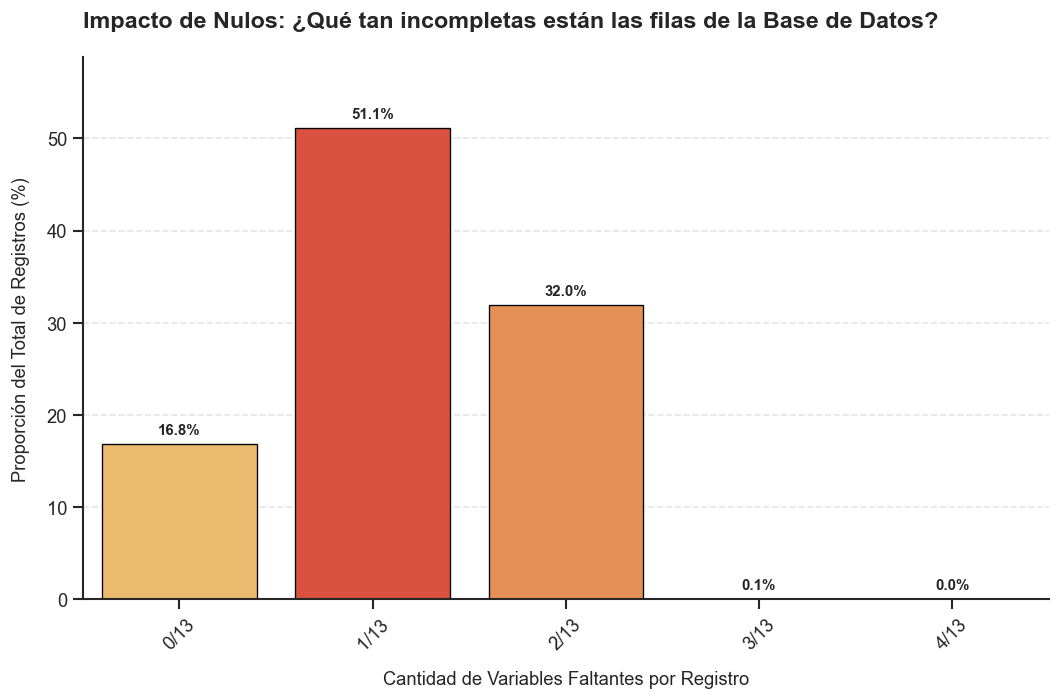


Análisis de Completitud: Comportamiento por Variables
--------------------------------------------------------------
🔹 Formato Tabular de los Resultados Obtenidos: 
--------------------------------------------------------------

              identificador  porcentaje
6           razon_intereses       60.04
8                     grado        5.15
9                 sub_grado        5.14
7          pago_mensual_EUR        5.01
1            fecha_prestamo        5.00
5            meses_prestamo        5.00
4   aceptacion_prestamo_EUR        5.00
2    solicitud_prestamo_EUR        5.00
3           estado_prestamo        5.00
11                   estado        5.00
10      estado_verificacion        5.00
12       pago_efectuado_EUR        5.00
0             identificador        0.00

--------------------------------------------------------------
🔹 Análisis Cuantitativo de la Completitud de la Base de Datos por Variables
--------------------------------------------------------------

    To

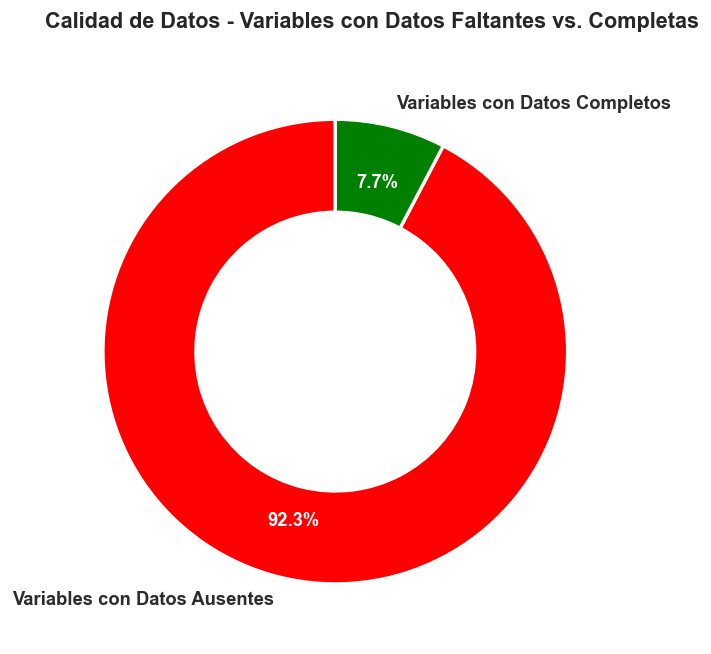


--------------------------------------------------------------
📊 Severidad del Impacto de Datos Faltantes por Variable:
--------------------------------------------------------------



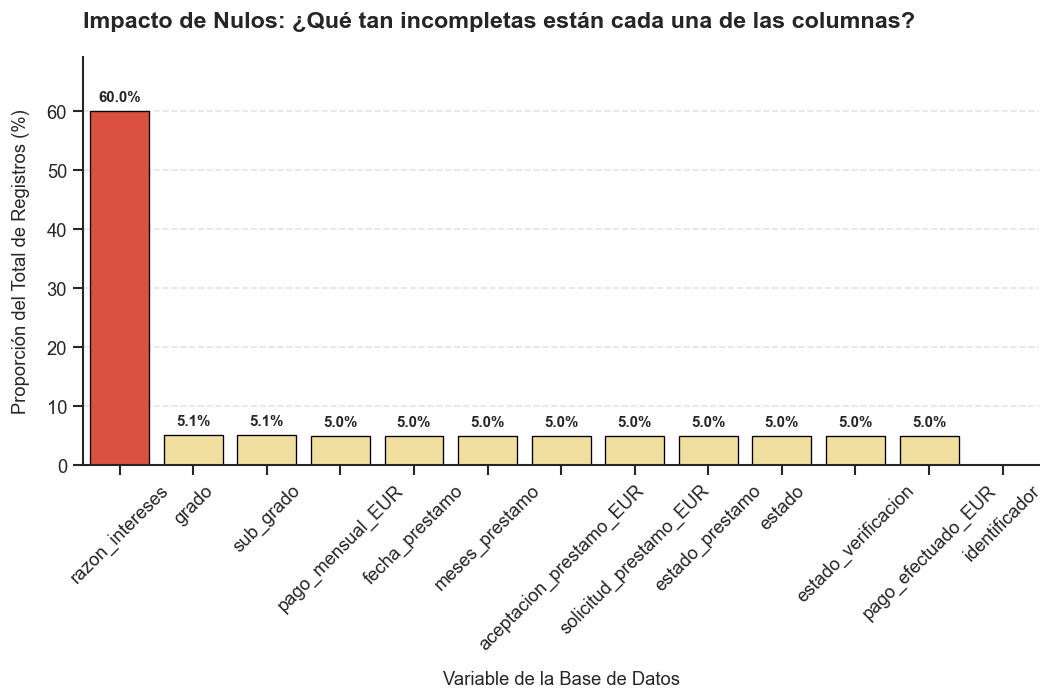

--------------------------------------------------------------
📊 Cantidad de variables por rango de datos ausentes:
--------------------------------------------------------------



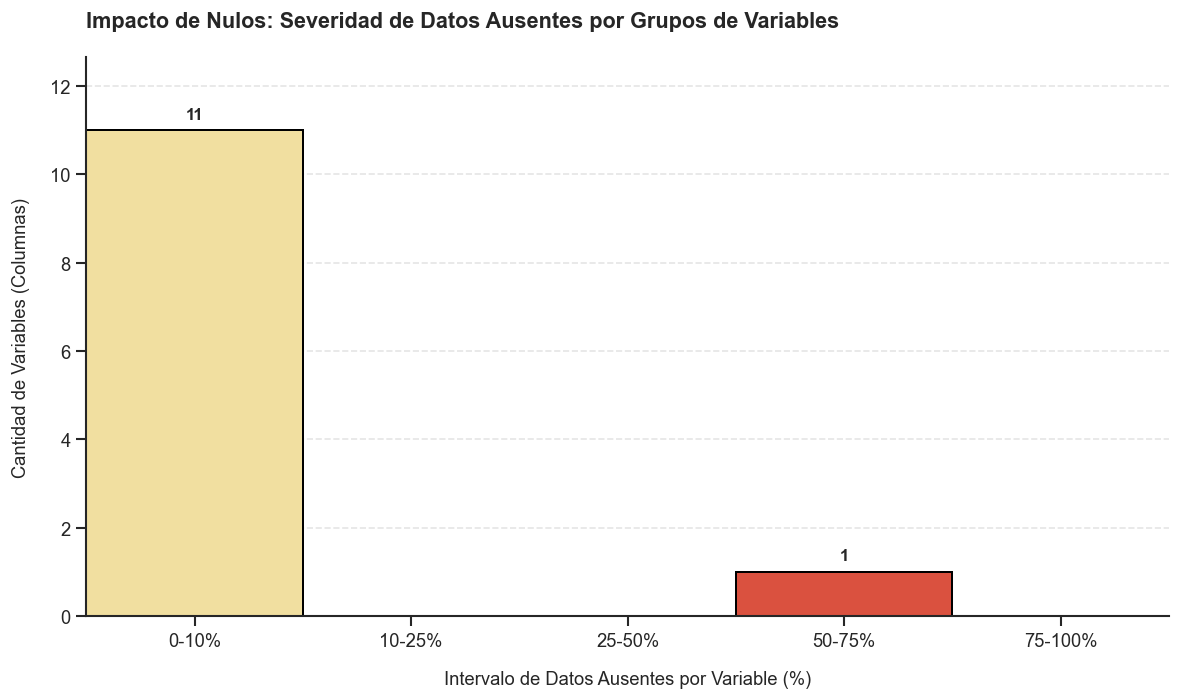



--------------------------------------------------------------
📊 Severidad del Impacto de Datos Faltantes por Variable Relativo al Total de Valores Nulos:
--------------------------------------------------------------



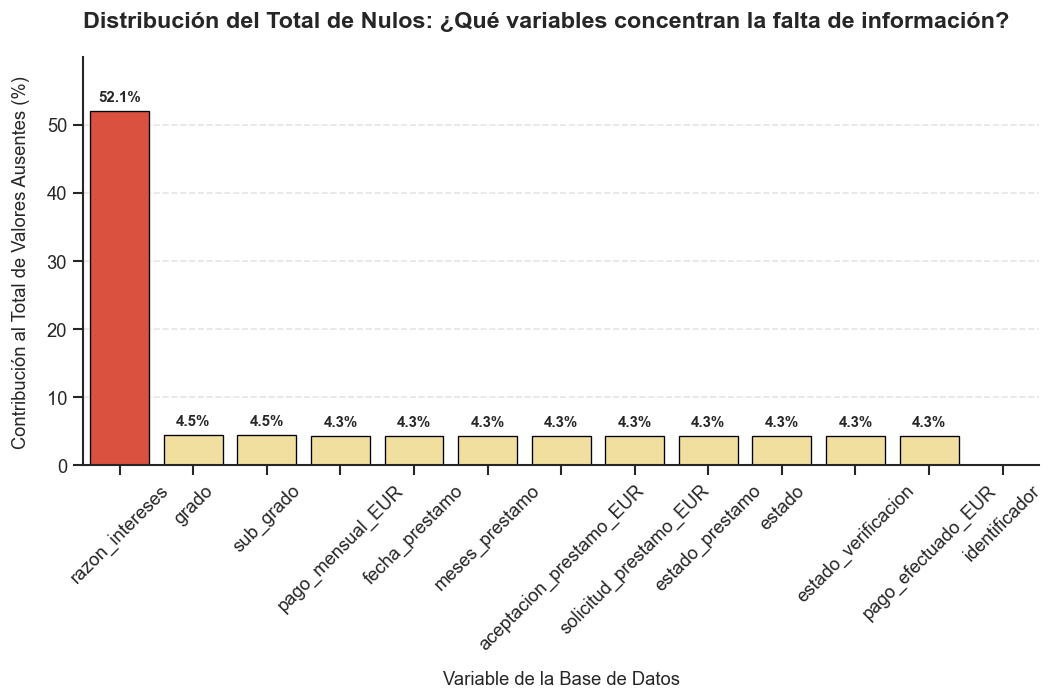

--------------------------------------------------------------
📊 Cantidad de Variables por Rango de Concentración de Datos Ausentes:
--------------------------------------------------------------



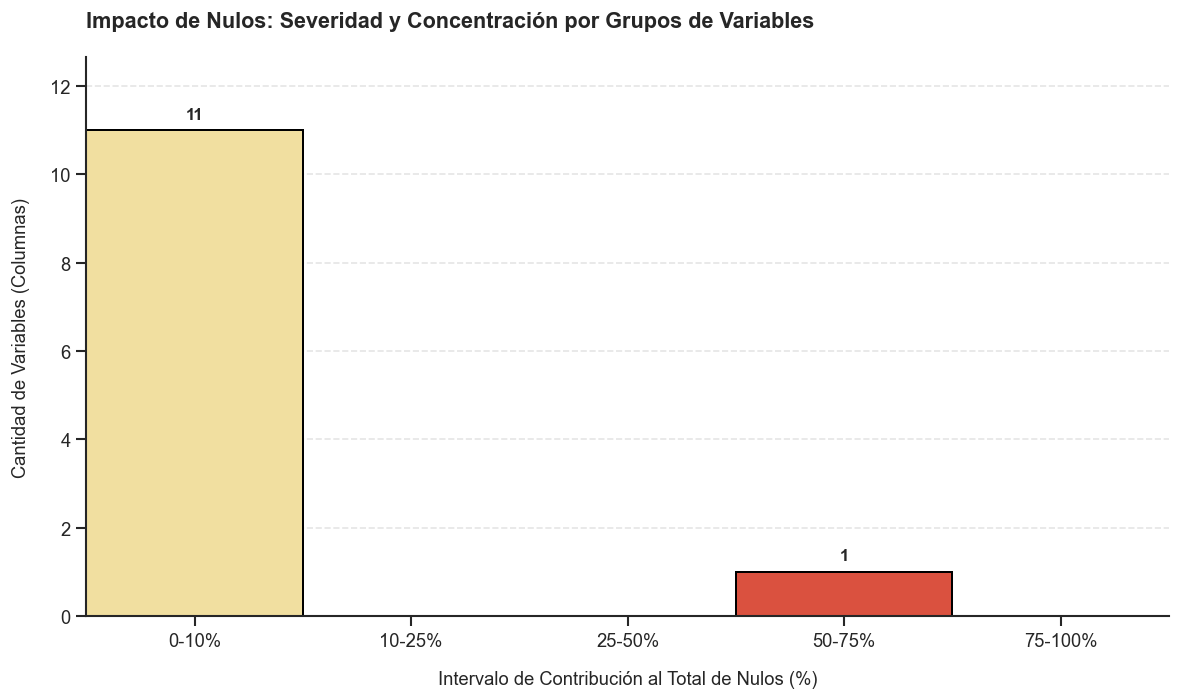

In [184]:
analisis_completitud(datos=datos_pandas)

#####  ⭐ *Observaciones*

___


A partir de las métricas analíticas y las representaciones gráficas obtenidas en el diagnóstico de calidad, se desprenden las siguientes conclusiones clave:

* *Dimensión y Ajuste de la Estructura*: La base de datos comprende un total de **130 000** datos, estructuradas en **10 000** registros (filas) y **13** variables (columnas). Cabe destacar que el diseño original contaba con **14** variables; sin embargo, tras identificar redundancia crítica en variables categóricas como elementos únicos de identificación, una de ellas (`enlace`) fue removida por completo para optimizar el conjunto de datos. 

* *Magnitud Global de Valores Ausentes*: Se detectó un volumen total de **11 534** valores ausentes, lo que representa el **8.87 %** de la matriz global de datos. En consecuencia, el Índice Global de Completitud se sitúa en un sólido **91.13 %**, lo que demuestra que la mayor parte de la información requerida se encuentra disponible.

* *Comportamiento por Registros* (**Filas**):

    - *Diagnóstico de Completitud*: El **83.17 %** de las filas (**8 317** registros) presenta al menos una incidencia de nulos, lo que significa que solo el **16.83 %** de los registros está **100 %** limpio.

    - *Dispersión y Severidad*: El fenómeno está ampliamente generalizado pero es superficial; la gran mayoría de las filas omiten únicamente una o dos variables. La presencia de registros con una pérdida superior al **15.38 %** (más de dos campos vacíos) es marginal, registrándose un escenario crítico máximo de incompletitud del **30.77 %** (cuatro variables nulas en una misma fila).

* *Comportamiento por Variables* (**Columnas**):

    - *Diagnóstico de Completitud*: Excluyendo la columna identificador (que está **100 %** completa), el **92.31 %** de las variables (**12** de **13**) presenta algún grado de información faltante.

    - *Focalización del Problema*: La distribución de nulos es altamente asimétrica. Existe una concentración crítica en la variable `tasa_intereses`, la cual supera el **60 %** de datos ausentes relativo al total de registros. En contraste, el resto de las **11** variables afectadas exhibe un comportamiento homogéneo, con tasas de ausencia que no superan el **6 %**.

    - *Severidad e Impacto Global*: El volumen de datos faltantes en `tasa_intereses` equivale a poco más de la mitad de los registros nulos de todo el dataset (**52.1 %**). Este hecho confirma el impacto desproporcionado de esta variable sobre la integridad global de la base de datos y la perfila como el principal foco de atención para el proceso de limpieza o imputación.

Estos indicadores demuestran un escenario analítico particular: 
- Aunque el volumen global de datos faltantes es reducido (**8.87 %**), su dispersión es masiva, afectando al **83.17 %** de los registros y al **92.31 %** de las variables.

El problema no radica en la pérdida masiva de información general, sino en que las ausencias están "salpicadas" por toda la estructura, comprometiendo la integridad de casi cualquier fila si se intentara un análisis directo. Asimismo, el caso crítico de `tasa_intereses` (**>60 %** de nulos) requiere una estrategia de tratamiento aislada. 

Estos hallazgos justifican plenamente el diseño y la aplicación de técnicas avanzadas de limpieza, segmentación e imputación antes de proceder con cualquier análisis estadístico posterior.

---

###  **Métricas de Duplicidad de Datos**

Análisis de Duplicidad de Datos: Comportamiento por Registros
--------------------------------------------------------------
🔹 Formato Tabular de los Resultados Obtenidos: 
--------------------------------------------------------------

<bound method Series.sort_values of Series([], Name: count, dtype: int64)>

--------------------------------------------------------------
🔹 Análisis Cuantitativo de la Completitud de la Base de Datos por Variables
--------------------------------------------------------------

    Cantidad de registros duplicados: 0
    Cantidad de registros únicos: 10000
    Total de registros: 10000
    Proporción de registros duplicados relativo a los registros únicos: 0.0 %
    Índice de unicidad de los registros: 1.0 %

--------------------------------------------------------------
🔹 Formato Gráfico de los Resultados Obtenidos: 
--------------------------------------------------------------



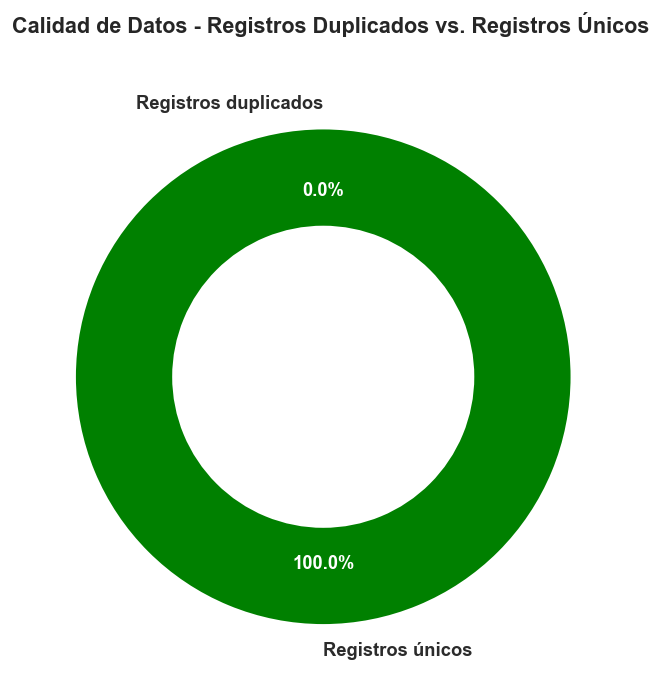

In [198]:
duplicidad_unicidad_registros(datos=datos_pandas)

###  **Métricas de Duplicidad de Datos**

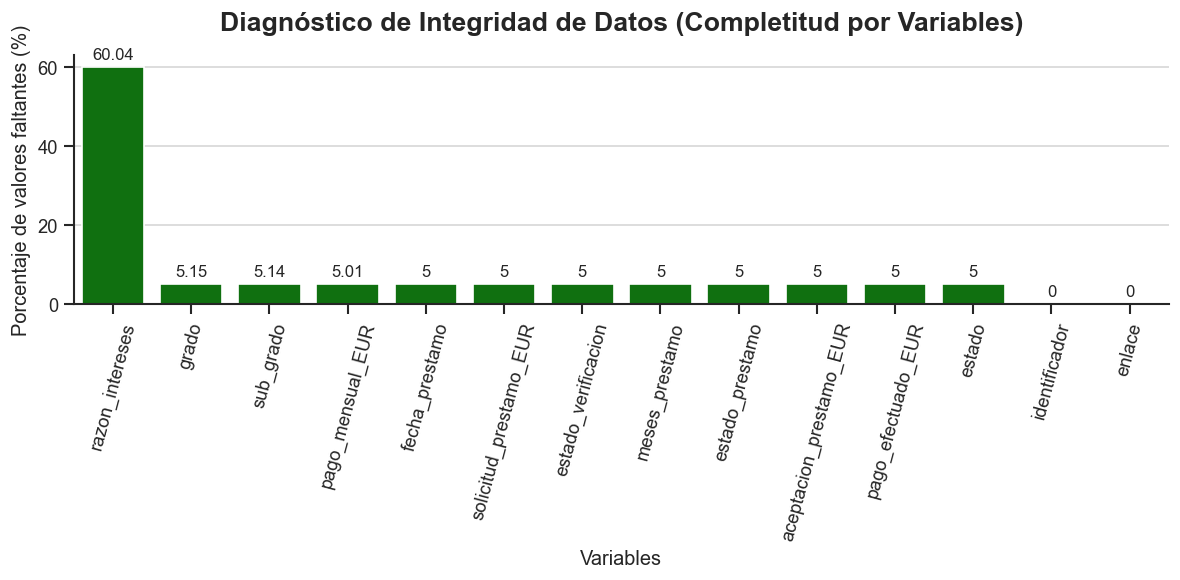

In [49]:
generacion_grafico_barra(
    datos=completitud_variables_ordenado,
    columnas=completitud_variables_ordenado.columns,
    titulo='Diagnóstico de Integridad de Datos (Completitud por Variables)',
    xlabel='Variables',
    ylabel='Porcentaje de valores faltantes (%)',
    ancho=10
)

##### ⭐ *Observaciones*

___
___

A partir de los resultados obtenidos en la gráfica correspondiente a la caracterización de valores ausentes por cada una de las variables de la base de datos, se establecen las siguientes conclusiones:

- La variable `razon_interes` presenta el mayor porcentaje de valores faltantes del conjunto de datos. En consecuencia, si no es posible aplicar una estrategia de imputación adecuada, la información disponible para esta variable resulta limitada para realizar análisis posteriores, ya que el **60.04 %** de sus registros se encuentra ausente.

- Las variables `identificador` y `enlace` presentan un **100 %** de completitud, por lo que no requieren la aplicación de procedimientos de imputación relacionados con la presencia de valores faltantes.

- Las demás variables presentan bajos porcentajes de valores faltantes **(~5 %)**. No obstante, su nivel de integridad puede mejorarse mediante la aplicación de técnicas de imputación, siempre que estas se encuentren debidamente justificadas y fundamentadas en la relación existente entre las variables del conjunto de datos.

---
___

#####  *Completitud por registro*

In [50]:
completitud_registros_pandas = completitud_registros_datos(datos=datos_pandas)

   Cantidad_nulos  Porcentaje
2               0       16.83
0               1       51.11
1               2       31.96
3               3        0.09
4               4        0.01


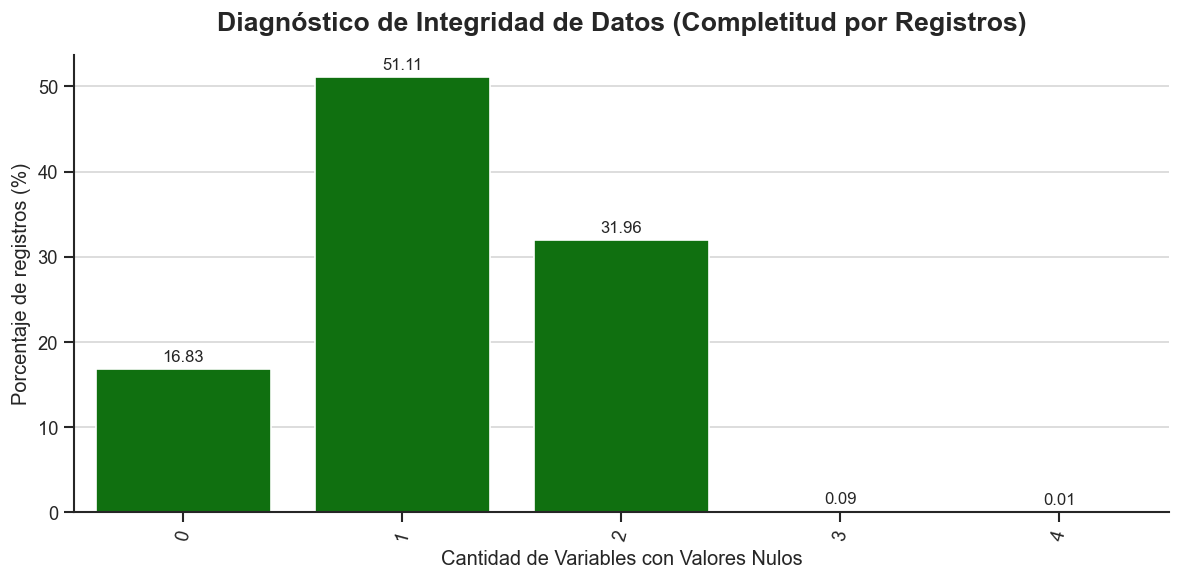

In [51]:
generacion_grafico_barra(
    datos=completitud_registros_pandas,
    columnas=completitud_registros_pandas.columns,
    titulo='Diagnóstico de Integridad de Datos (Completitud por Registros)',
    xlabel='Cantidad de Variables con Valores Nulos',
    ylabel='Porcentaje de registros (%)',
    ancho=10
)

##### ⭐ *Observaciones*


___
___

En los resultados obtenidos se observa que el **51.11 %** de los registros de la base de datos presenta únicamente una variable con un valor faltante. Este resultado pone de manifiesto la importancia de implementar un proceso de imputación, ya que, de no realizarse, una proporción considerable de los registros podría descartarse durante las etapas posteriores de análisis, reduciendo el tamaño efectivo de la muestra y la representatividad de los resultados.

Asimismo, el **31.96 %** de los registros contiene dos variables con valores faltantes. Esta situación evidencia la existencia de un grado apreciable de concurrencia de datos ausentes dentro de un mismo registro, fenómeno que probablemente se encuentra influenciado por la elevada proporción de valores faltantes observada en la variable correspondiente a la tasa de interés. En consecuencia, la ausencia de información en dicha variable incrementa la probabilidad de que un registro acumule más de un dato faltante.

Por otra parte, los registros que presentan tres o más valores faltantes representan únicamente el **0.10 %** del conjunto de datos, por lo que su incidencia resulta prácticamente despreciable. Este comportamiento es consistente con el hecho de que únicamente una variable exhibe una proporción elevada de valores ausentes, mientras que el resto presenta porcentajes de datos faltantes considerablemente menores. En consecuencia, no se observa evidencia de un patrón de ausencia que afecte simultáneamente a un gran número de variables dentro de un mismo registro, aunque serían necesarios análisis adicionales para determinar formalmente el mecanismo de ausencia de los datos (MCAR, MAR o MNAR).

Finalmente, solo el **16.83 %** de los registros conserva la totalidad de sus variables sin valores faltantes, lo que indica que más del **83 %** de la información disponible requiere algún tipo de tratamiento previo antes de ser utilizada en procesos analíticos. Este resultado justifica la implementación de un procedimiento sistemático de limpieza e imputación de datos, siempre que las técnicas empleadas se encuentren debidamente fundamentadas y sean consistentes con la naturaleza de las variables y con el mecanismo de generación de los valores ausentes.
___
___

####  **Métricas de Unicidad / Duplicidad de Datos**

___
___

A continuación, se realiza un análisis de la duplicidad presente en el conjunto de datos, con el objetivo de identificar tanto la existencia de registros redundantes como la presencia de valores duplicados en las variables de identificación de registros que han sido proveídas. Este análisis permite evaluar la unicidad de la información y detectar posibles inconsistencias derivadas de la repetición de datos.

Las métricas consideradas en esta etapa son las siguientes:

* Cantidad total de registros duplicados en el conjunto de datos.

* Cantidad de valores duplicados por cada una de las variables de identificación.

El análisis conjunto de estos indicadores permite identificar la existencia de información redundante y determinar si la presencia de registros o valores repetidos puede afectar la representatividad del conjunto de datos. Los resultados obtenidos constituyen un criterio fundamental para decidir la aplicación de procedimientos de eliminación de duplicados o de consolidación de registros antes de continuar con las etapas posteriores de limpieza y preprocesamiento.

___
___

##### *Registros duplicados*

In [52]:
registros_duplicados = datos_pandas.duplicated().sum()
total_registros = datos_pandas.shape[0]
print(f'Cantidad de registros duplicados: {registros_duplicados}')
print(f'Total de registros: {total_registros}')
print(f'Proporción de registros duplicados: {round(registros_duplicados/total_registros*100, 2)} %')
print(f'Índice de unicidad de los registros: {round((1 - registros_duplicados/total_registros)*100, 2)} %')

Cantidad de registros duplicados: 0
Total de registros: 10000
Proporción de registros duplicados: 0.0 %
Índice de unicidad de los registros: 100.0 %


#####  *Identificadores duplicados*

In [53]:
identificadores_duplicados = datos_pandas[etiquetas[0]].duplicated().sum()
total_registros = datos_pandas['identificador'].shape[0]
print(f'Cantidad de identificadores duplicados: {identificadores_duplicados}')
print(f'Total de registros: {total_registros}')
print(f'Proporción de identificadores duplicados: {round(identificadores_duplicados/total_registros*100, 2)} %')
print(f'Índice de unicidad de los identificadores: {round((1 - identificadores_duplicados/total_registros)*100, 2)} %')

Cantidad de identificadores duplicados: 0
Total de registros: 10000
Proporción de identificadores duplicados: 0.0 %
Índice de unicidad de los identificadores: 100.0 %


##### ⭐ *Observaciones*

___
___

A partir de los indicadores obtenidos se establecen las siguientes conclusiones:

- No se identificaron registros duplicados en la base de datos. Este resultado indica que cada observación representa un préstamo diferente y que no existen registros redundantes que puedan introducir sesgos en los análisis estadísticos.

- La totalidad de los 10 000 registros corresponden a observaciones únicas, por lo que el índice de unicidad de los registros es del **100 %**. En consecuencia, no es necesario aplicar procedimientos de eliminación de registros duplicados durante la etapa de limpieza de datos.

- Asimismo, no se detectaron identificadores duplicados, lo que confirma que la variable identificador cumple adecuadamente su función como clave única del conjunto de datos. Esta propiedad garantiza que cada préstamo puede ser identificado de manera unívoca.

- La ausencia simultánea de registros duplicados y de identificadores repetidos constituye un indicador favorable de la integridad estructural del conjunto de datos, ya que evidencia que no existen problemas asociados a la replicación accidental de información.

Aunque no fue necesario realizar acciones correctivas en esta etapa, la verificación de la unicidad de los registros y de los identificadores representa una buena práctica dentro del proceso de limpieza de datos, puesto que permite descartar de forma temprana posibles inconsistencias que podrían afectar la calidad de los análisis posteriores.

___
___

##### 🛠️ *Cambios efectuados*

Eliminación de registros duplicados

In [54]:
datos_pandas = datos_pandas.drop_duplicates()

Sería importante analizar los casos en los cuales la variable de identificación posea un duplicado posterior al proceso de eliminación realizado

In [55]:
datos_pandas[datos_pandas['identificador'].duplicated()]

,identificador,fecha_prestamo,solicitud_prestamo_EUR,estado_prestamo,aceptacion_prestamo_EUR,meses_prestamo,razon_intereses,pago_mensual_EUR,grado,sub_grado,estado_verificacion,enlace,estado,pago_efectuado_EUR


####  **Métricas de Cardinalidad de Datos**

___
___

Una vez evaluadas la completitud y la unicidad del conjunto de datos, resulta conveniente analizar la cardinalidad de las variables que lo componen. La cardinalidad se refiere al número de valores distintos que puede tomar una variable dentro del conjunto de datos y constituye una característica fundamental para comprender la naturaleza de la información almacenada.

El estudio de la cardinalidad permite:

* Diferenciar variables identificadoras, variables numéricas continuas y variables categóricas.

* Detectar posibles anomalías relacionadas con la presencia de valores inesperados, categorías mal definidas o una variabilidad inferior o superior a la esperada. 

* Proporciona información útil para la selección de estrategias de codificación, agrupación de categorías y reducción de variables durante las etapas posteriores del preprocesamiento de datos.

Las métricas consideradas en esta etapa son las siguientes:

- Cardinalidad absoluta por variable.

- Cardinalidad relativa por variable.

- Clasificación de la cardinalidad de las variables.

- Comparación entre la clasificación de la cardinalidad de los datos y el formato aplicado a cada una de las variables

El análisis conjunto de estos indicadores permite caracterizar el grado de diversidad de la información contenida en cada variable y evaluar si dicha diversidad es consistente con la naturaleza de los datos que representa.

___
___

##### *Cardinalidad Absoluta*

___
___

La cardinalidad absoluta se corresponde a la cantidad de valores únicos presentes en cada una de las variables que componen la base de datos proveída.
___
___

In [56]:
unicos_pandas = pd.DataFrame({
    'Categoría': etiquetas,
    'Cantidad de Valores Unicos': datos_pandas[etiquetas].fillna('N/A').nunique().values
})

unicos_pandas_ordenados = unicos_pandas.sort_values('Cantidad de Valores Unicos', ascending=False)

unicos_pandas.head()

,Categoría,Cantidad de Valores Unicos
0,identificador,10000
1,fecha_prestamo,13
2,solicitud_prestamo_EUR,886
3,estado_prestamo,9
4,aceptacion_prestamo_EUR,890


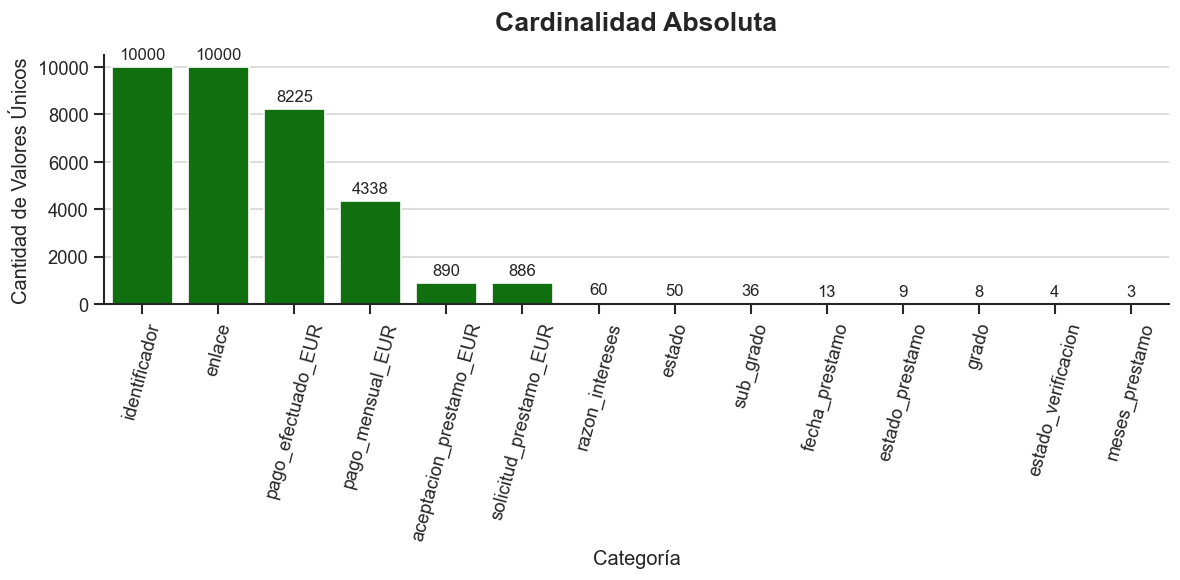

In [57]:
generacion_grafico_barra(
    datos=unicos_pandas_ordenados,
    columnas=unicos_pandas.columns,
    xlabel='Categoría',
    ylabel='Cantidad de Valores Únicos',
    titulo='Cardinalidad Absoluta',
    ancho=10
)

##### ⭐ *Observaciones*

___
___

A partir del análisis de la cardinalidad absoluta de las variables que conforman la base de datos, se obtienen las siguientes conclusiones:

* Las variables `identificador` y `enlace` presentan **10 000** valores únicos, equivalentes al número total de registros del conjunto de datos. Esta característica confirma que ambas variables pueden emplearse como identificadores únicos de cada observación. Sin embargo, debido a que ambas cumplen una función similar, es conveniente evaluar la posible redundancia de la información que contienen.

* Las variables `pago_efectuado_EUR` y `pago_mensual_EUR` presentan una cardinalidad elevada, con **8 225** y **4 338** valores únicos, respectivamente. Este comportamiento es consistente con la naturaleza continua de las variables monetarias, en las cuales es esperable una amplia diversidad de valores debido a las diferencias existentes entre los préstamos otorgados y los pagos realizados.

* Las variables `aceptacion_prestamo_EUR` y `solicitud_prestamo_EUR` presentan una cardinalidad intermedia (**890** y **886** valores únicos, respectivamente), lo que indica que, aunque existe una diversidad considerable de montos, diferentes registros comparten los mismos valores. Este comportamiento es habitual en variables financieras cuyos importes suelen concentrarse alrededor de determinados montos de referencia.

* La variable `razon_intereses` presenta únicamente **60** valores únicos, comportamiento consistente con una tasa de interés que únicamente puede tomar un conjunto limitado de valores. No obstante, este resultado debe analizarse conjuntamente con el estudio de completitud, ya que la elevada proporción de valores ausentes identificada previamente puede haber reducido la diversidad observada.

* La variable `estado` contiene **50** valores únicos, resultado que coincide con el número de estados que conforman los Estados Unidos. Esto sugiere que la cobertura geográfica del conjunto de datos es consistente con el dominio esperado para dicha variable.

* Las variables `sub_grado`, `grado`, `estado_prestamo`, `estado_verificacion`, `fecha_prestamo` y `meses_prestamo` presentan una baja cardinalidad. Este comportamiento es coherente con su naturaleza categórica, ya que representan atributos cuyos valores pertenecen a un conjunto reducido y previamente definido de categorías.

En términos generales, la distribución de la cardinalidad es consistente con la función que desempeña cada variable dentro del conjunto de datos. No se identifican anomalías que indiquen una diversidad excesiva o insuficiente de valores respecto a la naturaleza esperada de la información almacenada.
___
___

##### *Cardinalidad Relativa*

___
___

La cardinalidad relativa se define como la proporción de valores únicos que presenta una variable con relación al número total de registros del conjunto de datos. Esta métrica constituye una medida normalizada de la diversidad de los valores contenidos en cada variable, lo que permite comparar su comportamiento entre diferentes bases de datos sin que el tamaño de la muestra influya en la interpretación de los resultados. En consecuencia, la cardinalidad relativa representa un criterio útil para la clasificación de variables y el análisis de la estructura del conjunto de datos.

___
___

In [58]:
unicos_pandas_proporcion = unicos_pandas.copy()
unicos_pandas_proporcion['Proporcion'] = unicos_pandas_proporcion['Cantidad de Valores Unicos']/datos_pandas.shape[0]*100
unicos_pandas_proporcion = unicos_pandas_proporcion.drop('Cantidad de Valores Unicos', axis=1)
unicos_pandas_proporcion_ordenados = unicos_pandas_proporcion.sort_values('Proporcion', ascending=False)
unicos_pandas_proporcion.head()

,Categoría,Proporcion
0,identificador,100.00
1,fecha_prestamo,0.13
2,solicitud_prestamo_EUR,8.86
3,estado_prestamo,0.09
4,aceptacion_prestamo_EUR,8.90


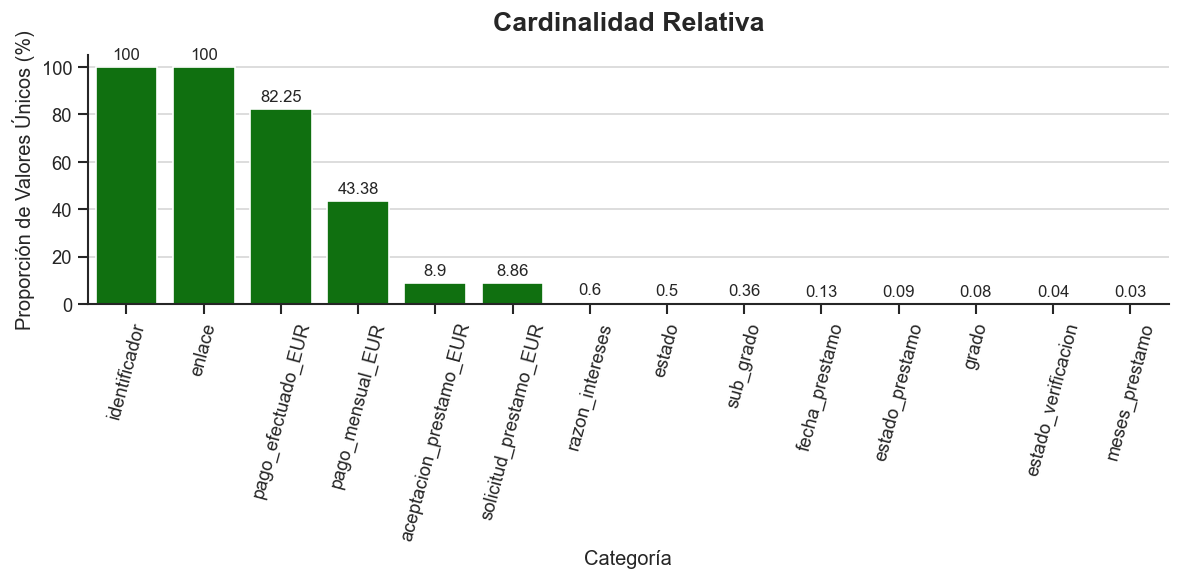

In [59]:
generacion_grafico_barra(
    datos=unicos_pandas_proporcion_ordenados,
    columnas=unicos_pandas_proporcion_ordenados.columns,
    xlabel='Categoría',
    ylabel='Proporción de Valores Únicos (%)',
    titulo='Cardinalidad Relativa',
    ancho=10
)

##### ⭐ *Observaciones*

___
___

Los resultados obtenidos son consistentes con los presentados en el análisis de cardinalidad absoluta, ya que la cardinalidad relativa constituye una versión normalizada de dicho indicador. 

En particular, se verifica que las variables `identificador` y `enlace` presentan una cardinalidad relativa del 100 %, lo que confirma que cada registro posee un valor único para ambas variables. Este comportamiento es característico de variables utilizadas como identificadores y sugiere la posible existencia de redundancia de información entre ellas, aspecto que deberá analizarse en etapas posteriores.

Adicionalmente, la cardinalidad relativa proporciona un criterio objetivo para clasificar las variables según su grado de diversidad, independientemente del tamaño del conjunto de datos. Resulta conveniente comparar esta clasificación con la obtenida durante la etapa inicial del análisis exploratorio, en la cual las variables fueron clasificadas de acuerdo con el formato de los datos que contienen (numéricas o no numéricas).

La comparación entre ambos criterios de clasificación permite detectar posibles inconsistencias o anomalías. Por ejemplo, una variable identificada inicialmente como categórica podría presentar una cardinalidad muy elevada, indicando que en realidad se comporta como un identificador o una variable continua. De forma análoga, una variable clasificada como numérica podría exhibir una cardinalidad reducida, lo que sugeriría que representa un conjunto limitado de categorías codificadas mediante valores numéricos. En consecuencia, el análisis conjunto del tipo de dato y de la cardinalidad proporciona una caracterización más completa de la naturaleza de las variables que integran el conjunto de datos.
___
___

##### *Clasificación de la Cardinalidad*

___
___

Con el propósito de facilitar la interpretación de los resultados obtenidos, las variables se clasifican de acuerdo con su cardinalidad relativa, empleando un conjunto de intervalos definidos específicamente para el presente estudio. Esta clasificación constituye un criterio metodológico orientado a caracterizar el grado de diversidad de los valores contenidos en cada variable y a facilitar la comparación entre ellas, independientemente del tamaño del conjunto de datos.

La clasificación adoptada es la siguiente:

- **Cardinalidad muy alta**: mayor que **80 %**.
- **Cardinalidad alta**: entre **20 %** y **80 %**.
- **Cardinalidad media**: entre **5 %** y **20 %**.
- **Cardinalidad baja**: entre **1 %** y **5 %**.
- **Cardinalidad muy baja**: menor que **1 %**.

Esta clasificación se emplea únicamente con fines descriptivos y de interpretación, permitiendo identificar de manera sistemática variables con un elevado grado de diversidad, variables predominantemente categóricas y posibles variables que desempeñan funciones de identificación dentro del conjunto de datos.

___
___

In [60]:
unicos_pandas_clasificados = unicos_pandas_proporcion.copy()

# Clasificación por defecto
unicos_pandas_clasificados['Clasificacion'] = 'Muy baja'

dict_umbrales = {
    1: 'Baja',
    5: 'Media',
    20: 'Alta',
    80: 'Muy alta'
}

for umbral, clasificacion in dict_umbrales.items():
    unicos_pandas_clasificados.loc[
        unicos_pandas_clasificados['Proporcion'] > umbral,
        'Clasificacion'
    ] = clasificacion

unicos_pandas_clasificados = unicos_pandas_clasificados.drop('Proporcion', axis=1)

unicos_pandas_clasificados[:]

,Categoría,Clasificacion
0,identificador,Muy alta
1,fecha_prestamo,Muy baja
2,solicitud_prestamo_EUR,Media
3,estado_prestamo,Muy baja
4,aceptacion_prestamo_EUR,Media
5,meses_prestamo,Muy baja
6,razon_intereses,Muy baja
7,pago_mensual_EUR,Alta
8,grado,Muy baja
9,sub_grado,Muy baja


In [61]:
distribucion_clasificaciones_pandas = pd.DataFrame(unicos_pandas_clasificados.value_counts('Clasificacion').reset_index())
distribucion_clasificaciones_pandas

,Clasificacion,count
0,Muy baja,8
1,Muy alta,3
2,Media,2
3,Alta,1


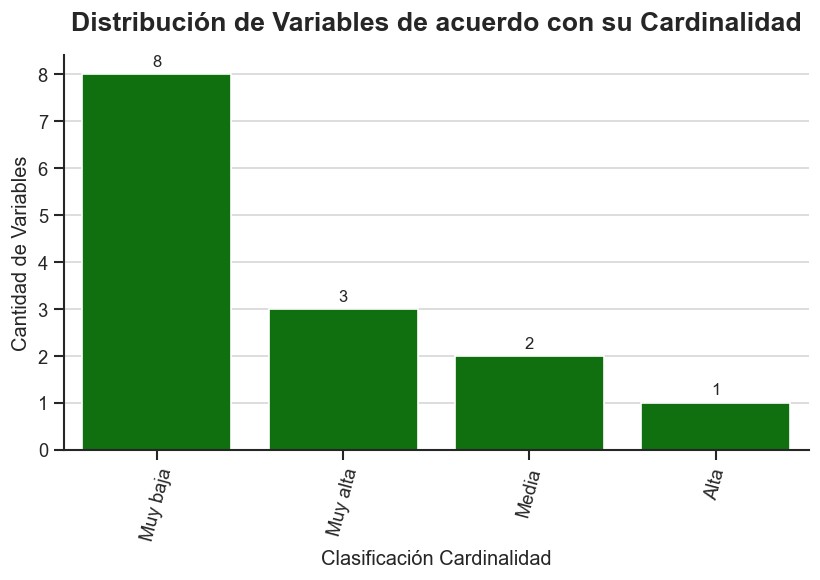

In [62]:
generacion_grafico_barra(
     datos=distribucion_clasificaciones_pandas,
     columnas=distribucion_clasificaciones_pandas.columns,
     titulo='Distribución de Variables de acuerdo con su Cardinalidad',
     xlabel='Clasificación Cardinalidad',
     ylabel='Cantidad de Variables'
)

##### ⭐ *Observaciones*

___
___

A partir de la clasificación de las variables según su cardinalidad relativa, se obtienen las siguientes conclusiones:

* La mayor parte de las variables de la base de datos (8 de las 14 variables analizadas) presentan una cardinalidad muy baja, lo que indica que están compuestas por un número reducido de valores distintos con relación al total de registros. Este comportamiento es característico de variables categóricas o de variables cuyos valores pertenecen a un dominio previamente definido.

* Se identifican tres variables con cardinalidad muy alta, las cuales presentan una elevada diversidad de valores. Este resultado es consistente con variables utilizadas como identificadores o con variables numéricas continuas, cuya naturaleza favorece la existencia de un gran número de valores distintos.

* Únicamente dos variables presentan una cardinalidad media, lo que evidencia una diversidad moderada de valores. Estas variables pueden corresponder a atributos numéricos discretos o a variables cuyos valores se encuentran concentrados en un conjunto limitado de posibilidades.

* Solo una variable fue clasificada con cardinalidad alta, indicando que, aunque existe una elevada diversidad de valores, esta no alcanza el nivel observado en las variables clasificadas como de cardinalidad muy alta.

En términos generales, la distribución de la cardinalidad refleja una estructura equilibrada y coherente con la naturaleza del conjunto de datos, en la que predominan las variables categóricas de baja diversidad y un grupo reducido de variables con elevada cardinalidad asociadas a identificadores y magnitudes numéricas.

La clasificación obtenida constituye un criterio complementario al análisis basado en el tipo de dato de las variables. Mientras que la clasificación inicial permite distinguir entre variables numéricas y no numéricas, el estudio de la cardinalidad proporciona información acerca del grado de diversidad de los valores que contiene cada variable. La combinación de ambos enfoques facilita la identificación de variables identificadoras, variables categóricas y variables numéricas, además de contribuir a la detección de posibles inconsistencias o anomalías en la estructura del conjunto de datos.
___
___

##### *Comparación Cardinalidad vs Formato*

In [63]:
unicos_pandas_comparacion = unicos_pandas_clasificados.copy()

unicos_pandas_comparacion.rename(
    columns={
        'Clasificacion' : 'Clasificacion Cardinalidad'
    }, inplace=True
)

unicos_pandas_comparacion['Clasificacion Formato'] = 'No Numérica'

unicos_pandas_comparacion.loc[unicos_pandas_comparacion['Categoría'].isin(columnas_numericas), 'Clasificacion Formato'] = 'Numérica'

unicos_pandas_comparacion[:]

,Categoría,Clasificacion Cardinalidad,Clasificacion Formato
0,identificador,Muy alta,No Numérica
1,fecha_prestamo,Muy baja,No Numérica
2,solicitud_prestamo_EUR,Media,Numérica
3,estado_prestamo,Muy baja,No Numérica
4,aceptacion_prestamo_EUR,Media,Numérica
5,meses_prestamo,Muy baja,No Numérica
6,razon_intereses,Muy baja,Numérica
7,pago_mensual_EUR,Alta,Numérica
8,grado,Muy baja,No Numérica
9,sub_grado,Muy baja,No Numérica


In [64]:
distribucion_categorica = (
    unicos_pandas_comparacion
    .groupby(
        ['Clasificacion Formato', 'Clasificacion Cardinalidad']
    )
    .size()
    .reset_index(name='Cantidad')
)

distribucion_categorica

,Clasificacion Formato,Clasificacion Cardinalidad,Cantidad
0,No Numérica,Muy alta,2
1,No Numérica,Muy baja,7
2,Numérica,Alta,1
3,Numérica,Media,2
4,Numérica,Muy alta,1
5,Numérica,Muy baja,1


In [65]:
distribucion_no_numerico = distribucion_categorica[distribucion_categorica['Clasificacion Formato']=='No Numérica'].drop('Clasificacion Formato', axis=1)
distribucion_no_numerico

,Clasificacion Cardinalidad,Cantidad
0,Muy alta,2
1,Muy baja,7


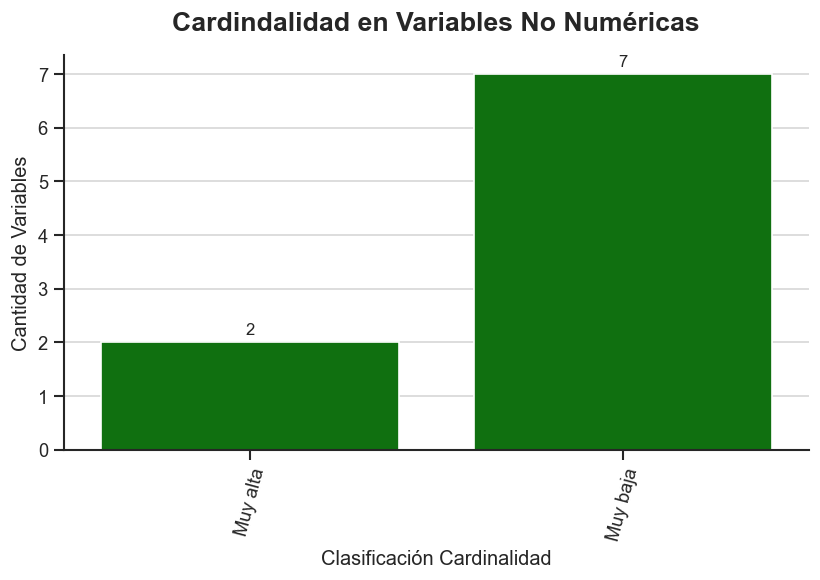

In [66]:
generacion_grafico_barra(
    datos=distribucion_no_numerico,
    columnas=distribucion_no_numerico.columns,
    titulo='Cardindalidad en Variables No Numéricas',
    xlabel='Clasificación Cardinalidad',
    ylabel='Cantidad de Variables'
)

In [67]:
distribucion_numerico = distribucion_categorica[distribucion_categorica['Clasificacion Formato']=='Numérica'].drop('Clasificacion Formato', axis=1)
distribucion_numerico

,Clasificacion Cardinalidad,Cantidad
2,Alta,1
3,Media,2
4,Muy alta,1
5,Muy baja,1


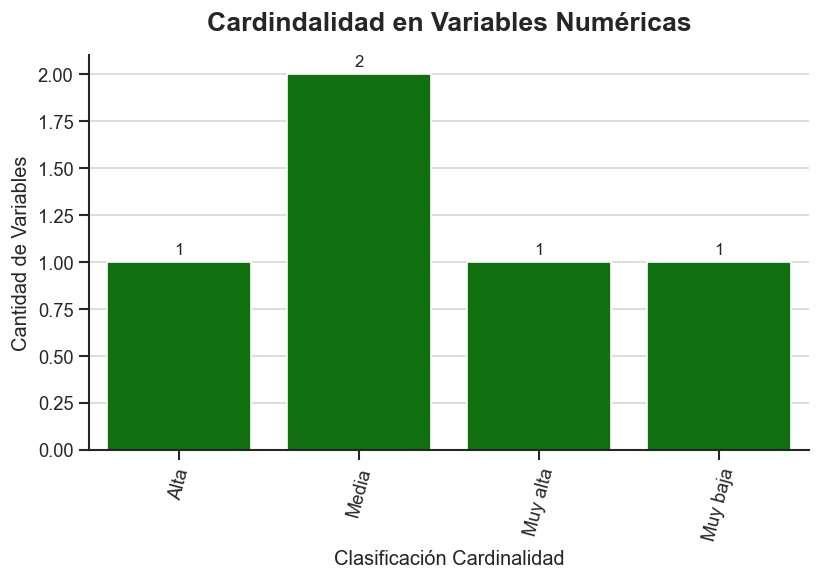

In [68]:
generacion_grafico_barra(
    datos=distribucion_numerico,
    columnas=distribucion_numerico.columns,
    titulo='Cardindalidad en Variables Numéricas',
    xlabel='Clasificación Cardinalidad',
    ylabel='Cantidad de Variables'
)

##### ⭐ *Observaciones*

___
___

A partir de la comparación entre la clasificación de las variables según su formato y su nivel de cardinalidad, se obtienen las siguientes conclusiones:

* La mayoría de las variables no numéricas (7 de 9) presentan una cardinalidad muy baja, lo cual es consistente con su naturaleza categórica. Este comportamiento indica que dichas variables están compuestas por un conjunto reducido de categorías, característica esperada en atributos como estados, grados o clasificaciones.

* Dentro del conjunto de variables no numéricas, únicamente dos variables presentan una cardinalidad muy alta. Este resultado corresponde a las variables `identificador` y `enlace`, las cuales fueron clasificadas inicialmente como no numéricas debido a su formato, pero cuya elevada cardinalidad confirma que desempeñan la función de identificadores únicos de los registros y no la de variables categóricas convencionales.

* Las variables numéricas presentan una distribución de cardinalidad más heterogénea. Se identifican variables con cardinalidad media, alta y muy alta, comportamiento esperado en variables cuantitativas asociadas a montos, pagos y tasas de interés, cuyos valores presentan diferentes niveles de variabilidad.

* Se identifica una variable numérica con cardinalidad muy baja, correspondiente a `razon_intereses`. En principio, este comportamiento podría sugerir que la variable está compuesta por un conjunto reducido de valores posibles, característica propia de variables categóricas codificadas mediante valores numéricos. Sin embargo, esta conclusión no puede establecerse únicamente a partir del análisis de la cardinalidad.

    Es importante considerar que razon_intereses presenta la mayor proporción de valores ausentes dentro del conjunto de datos, lo que puede reducir significativamente el número de valores únicos observados y afectar la estimación de su cardinalidad. Adicionalmente, al tratarse de una tasa de interés, es posible que los valores se encuentren discretizados o redondeados, circunstancia que también disminuiría el número de valores distintos sin modificar la naturaleza cuantitativa de la variable.

    En consecuencia, los resultados obtenidos constituyen un indicio de que esta variable requiere un análisis más detallado. En las etapas posteriores del proceso de preprocesamiento será necesario estudiar su distribución, la frecuencia de sus valores y el mecanismo asociado a la ausencia de datos, con el propósito de determinar si la baja cardinalidad responde a las características propias de la variable o si constituye una anomalía derivada de la calidad de los datos.

En conjunto, la comparación entre ambas clasificaciones confirma que el criterio basado en el formato de los datos y el criterio basado en la cardinalidad son complementarios. Mientras que el primero identifica la representación de los datos, el segundo caracteriza la diversidad de los valores contenidos en cada variable. La utilización conjunta de ambos enfoques permite describir con mayor precisión la naturaleza de las variables y detectar posibles excepciones que requieren un tratamiento específico durante las etapas posteriores de preprocesamiento.
___
___

##### 🛠️ *Cambios efectuados*

___
___

Al evaluar las variables de identificación en la base de datos, se detectó que las columnas identificador y enlace poseen una funcionalidad idéntica y redundante. Para simplificar la estructura del modelo y evitar la duplicidad de dimensiones informativas, se decidió conservar identificador y dar de baja la variable enlace. Esta acción correctiva reduce el peso del dataset sin comprometer la integridad ni la trazabilidad de los registros.

___
___

In [69]:
datos_pandas = datos_pandas.drop(columns=['enlace'])

In [70]:
columnas_no_numericas.remove('enlace')

### 🧠 **Análisis Semántico de Variables Categóricas**

___
___

A continuación, se lleva a cabo un análisis semántico de las variables que integran la base de datos con el objetivo de evaluar la consistencia entre el significado de los datos y la categorización asignada a cada variable. Este procedimiento permite identificar posibles discrepancias o inconsistencias que no hayan sido detectadas durante las etapas previas de análisis y validación de los datos.

___
___

In [71]:
datos_pandas[columnas_no_numericas].head()

,identificador,fecha_prestamo,estado_prestamo,meses_prestamo,grado,sub_grado,estado_verificacion,estado
0,48010226,May-15,Current,36 months,C,C3,Verified,CA
1,57693261,NaN,Current,36 months,A,A5,Source Verified,NY
2,59432726,Sep-15,Current,36 months,B,B5,Verified,PA
3,53222800,Jul-15,Current,36 months,A,A5,Not Verified,OH
4,57803010,Aug-15,Current,36 months,NaN,E3,Source Verified,TX


#### **Variable: Identificador**

___
La variable identificador presenta un formato compatible con valores numéricos. Sin embargo, como se determinó previamente, cada valor corresponde a un identificador único para cada registro de la base de datos. En consecuencia, se considera más apropiado conservar esta variable como un dato categórico representado mediante una cadena de caracteres, ya que sus valores cumplen una función de identificación y no poseen significado cuantitativo.

___
___
**Variable identificadora**
___
*no requiere modificación de momento*
___

#### **Variable: Fecha Préstamo**

In [72]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='fecha_prestamo'
)

Variable: fecha_prestamo

Número de categorías: 13
Valores nulos: 500

Frecuencia de las categorías:

fecha_prestamo
Oct-15             1095
Jul-15             1061
Dec-15              997
Nov-15              847
Aug-15              846
Jan-15              770
Apr-15              757
May-15              741
Jun-15              654
Sep-15              643
Mar-15              559
Feb-15              530
No especificado     500
Name: count, dtype: int64

Categorías registradas:
 - Apr-15
 - Aug-15
 - Dec-15
 - Feb-15
 - Jan-15
 - Jul-15
 - Jun-15
 - Mar-15
 - May-15
 - No especificado
 - Nov-15
 - Oct-15
 - Sep-15


##### *Observaciones*

___  
Variable: `fecha_prestamo`

La variable `fecha_prestamo` presenta **13** categorías, de las cuales:

- **12** corresponden a meses del año **2015**.  
- **1** representa valores ausentes (`No especificado`). 

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Los valores válidos siguen un formato homogéneo de mes-año (`Mes-AA`), lo que indica que la variable posee una **naturaleza temporal** y registra el mes en que fue otorgado cada préstamo.  

Se observa que la información disponible se encuentra completamente concentrada en el año **2015**, por lo que la variable no permite analizar variaciones interanuales, sino únicamente patrones mensuales dentro de dicho período, con una resolución temporal de tipo mensual.  

En consecuencia, resulta recomendable convertir esta variable a un tipo de dato de fecha (`datetime`) para facilitar su manipulación en análisis temporales y modelado posterior. Asimismo, la categoría `No especificado` debe tratarse como un valor ausente durante el preprocesamiento.

___  
___  

**Tipo de variable:** Temporal  

___  

**Recomendaciones:**
- Convertir la variable a tipo de dato `datetime` para habilitar análisis temporal.  
- Tratar la categoría `No especificado` como un valor ausente (`NaN`).  
- Utilizar la variable en análisis de estacionalidad mensual dentro del año 2015.  
___

##### *Modificaciones*

In [73]:
datos_pandas['fecha_prestamo'] = pd.to_datetime(datos_pandas['fecha_prestamo'], errors='coerce')
datos_pandas['fecha_prestamo'].dt.strftime('%b')

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_26676\1308668605.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datos_pandas['fecha_prestamo'] = pd.to_datetime(datos_pandas['fecha_prestamo'], errors='coerce')


0       May
1       NaN
2       Sep
3       Jul
4       Aug
       ... 
9995    Mar
9996    Apr
9997    Jun
9998    Apr
9999    Dec
Name: fecha_prestamo, Length: 10000, dtype: str

#### **Variable: Estado Préstamo**

In [74]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='estado_prestamo'
)

Variable: estado_prestamo

Número de categorías: 9
Valores nulos: 500

Frecuencia de las categorías:

estado_prestamo
Current               8538
Fully Paid             505
No especificado        500
Issued                 184
Late (31-120 days)     115
Charged Off             61
In Grace Period         56
Late (16-30 days)       30
Default                 11
Name: count, dtype: int64

Categorías registradas:
 - Charged Off
 - Current
 - Default
 - Fully Paid
 - In Grace Period
 - Issued
 - Late (16-30 days)
 - Late (31-120 days)
 - No especificado


##### *Observaciones*

___  
Variable: `estado_prestamo`

La variable `estado_prestamo` presenta **9** categorías, además de **500 valores ausentes** representados como `No especificado`.

Las categorías registradas describen la **situación actual del préstamo dentro de su ciclo de vida crediticio**, por lo que la variable corresponde a una **variable categórica nominal**, ya que no existe una jerarquía natural entre todos sus estados.

Se identifican categorías asociadas a distintos estados del crédito:

- **Préstamos activos:** `Current`, `Issued`, `In Grace Period`.  
- **Préstamos pagados:** `Fully Paid`.  
- **Estados de morosidad o incumplimiento:** `Late (16-30 days)`, `Late (31-120 days)`, `Charged Off`, `Default`.  

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Se observa un **fuerte predominio de la categoría `Current`**, lo que indica que la mayoría de los préstamos se encuentran activos. Asimismo, las categorías relacionadas con incumplimiento presentan frecuencias significativamente menores, lo que sugiere un posible **desbalance entre clases** relevante para análisis predictivos.

La categoría `No especificado` no corresponde a un estado válido del préstamo y debe tratarse como un valor ausente durante el preprocesamiento.

___  
___  

**Tipo de variable:** Categórica nominal  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Considerar el desbalance de clases en análisis predictivos.  
- Evaluar agrupación de estados de morosidad para simplificar análisis (opcional según objetivo).  
___

#### **Variable: Meses Préstamo**

In [75]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='meses_prestamo'
)

Variable: meses_prestamo

Número de categorías: 3
Valores nulos: 500

Frecuencia de las categorías:

meses_prestamo
 36 months         6281
 60 months         3219
No especificado     500
Name: count, dtype: int64

Categorías registradas:
 -  36 months
 -  60 months
 - No especificado


##### *Observaciones*

___  
Variable: `meses_prestamo`

La variable `meses_prestamo` presenta **3** categorías, además de **500 valores ausentes** representados como `No especificado`.

Los valores válidos corresponden al **plazo de amortización del préstamo**, expresado en meses, por lo que la variable posee una naturaleza de tipo **cuantitativa discreta representada como categoría**. En este caso, los valores observados indican que la institución financiera ofrece únicamente dos plazos de financiamiento: **36 y 60 meses**.

Se identifica la categoría `No especificado`, la cual no representa un plazo válido y debe ser tratada como un valor ausente durante el preprocesamiento.

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Dado que la variable únicamente toma dos valores numéricos posibles, también puede interpretarse como una variable **categórica ordinal**, debido a la existencia de una relación natural de orden entre los plazos (36 < 60), dependiendo del tipo de análisis a realizar.

___  
___  

**Tipo de variable:** Cuantitativa discreta / Categórica ordinal  

___  

**Recomendaciones:**
- Convertir la variable a formato numérico eliminando el sufijo `months`.  
- Tratar `No especificado` como valor ausente (`NaN`).  
- Evaluar su uso como variable ordinal o numérica según el modelo analítico.  
___

##### *Modificaciones*

In [76]:
datos_pandas['meses_prestamo'] = pd.to_numeric(datos_pandas['meses_prestamo'].str.strip().str.split((' ')).str[0], errors='coerce')
columnas_no_numericas.remove('meses_prestamo')
columnas_numericas.append('meses_prestamo')

In [77]:
datos_pandas[columnas_no_numericas].head()

,identificador,fecha_prestamo,estado_prestamo,grado,sub_grado,estado_verificacion,estado
0,48010226,1-05-15,Current,C,C3,Verified,CA
1,57693261,NaT,Current,A,A5,Source Verified,NY
2,59432726,1-09-15,Current,B,B5,Verified,PA
3,53222800,1-07-15,Current,A,A5,Not Verified,OH
4,57803010,1-08-15,Current,NaN,E3,Source Verified,TX


In [78]:
datos_pandas[columnas_numericas].head()

,solicitud_prestamo_EUR,aceptacion_prestamo_EUR,razon_intereses,pago_mensual_EUR,pago_efectuado_EUR,meses_prestamo
0,35000.0,35000.0,13.33,1184.86,9452.96,36.0
1,30000.0,30000.0,NaN,938.57,4679.70,36.0
2,15000.0,15000.0,NaN,494.86,1969.83,36.0
3,9600.0,9600.0,NaN,300.35,1793.68,36.0
4,8075.0,8075.0,19.19,296.78,1178.51,36.0


#### **Variable: Grado**

In [79]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='grado'
)

Variable: grado

Número de categorías: 8
Valores nulos: 515

Frecuencia de las categorías:

grado
C                  2766
B                  2606
A                  1632
D                  1389
E                   816
No especificado     515
F                   236
G                    40
Name: count, dtype: int64

Categorías registradas:
 - A
 - B
 - C
 - D
 - E
 - F
 - G
 - No especificado


##### *Observaciones*

___  
Variable: `grado`

La variable `grado` presenta **8** categorías, además de **515 valores ausentes** representados como `No especificado`.

Las categorías corresponden a una **clasificación de riesgo crediticio**, por lo que la variable se interpreta como una **variable categórica ordinal**, en la cual existe una jerarquía natural entre los niveles de riesgo.

Las categorías siguen un orden de menor a mayor riesgo:

- `A` representa el menor nivel de riesgo crediticio.  
- `G` representa el mayor nivel de riesgo crediticio.

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Se observa que la mayor concentración de registros se encuentra en los grados intermedios (`A`, `B`, `C` y `D`), mientras que las categorías de mayor riesgo (`F` y `G`) presentan frecuencias considerablemente menores. Esto sugiere un **desbalance en la distribución de las clases**, aspecto relevante en el caso de análisis predictivos o modelos de scoring.

La categoría `No especificado` no corresponde a un grado válido dentro de la escala ordinal y debe interpretarse como un valor ausente durante el preprocesamiento.

En consecuencia, la variable es consistente desde el punto de vista semántico y refleja adecuadamente una estructura ordinal de riesgo crediticio.

___  
___  

**Tipo de variable:** Categórica ordinal  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Mantener la estructura ordinal (`A < B < C < D < E < F < G`) en cualquier codificación.  
- Considerar el desbalance de clases en análisis posteriores.  

#### **Variable: Sub-Grado**

In [80]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='sub_grado'
)

Variable: sub_grado

Número de categorías: 36
Valores nulos: 514

Frecuencia de las categorías:

sub_grado
C1                 629
C3                 586
C2                 567
C4                 564
B4                 553
B3                 530
B2                 517
No especificado    514
B1                 509
A5                 502
B5                 494
C5                 423
D1                 391
A4                 323
A1                 285
A2                 278
D2                 267
D4                 255
D3                 250
A3                 239
E1                 235
D5                 223
E3                 171
E2                 162
E4                 139
E5                 114
F1                  94
F2                  52
F4                  43
F3                  34
G1                  19
F5                  16
G2                  10
G4                   7
G3                   3
G5                   2
Name: count, dtype: int64

Categorías registradas:
 - A1
 - A2
 -

##### *Observaciones*

___  
Variable: `sub_grado`

La variable `sub_grado` presenta **36** categorías, además de **514 valores ausentes** representados como `No especificado`.

Las categorías corresponden a una **desagregación del nivel de riesgo crediticio**, por lo que la variable se interpreta como una **variable categórica ordinal jerárquica**, derivada de la variable `grado`. Su estructura combina una letra (`A`–`G`) que indica el nivel general de riesgo, y un número (`1`–`5`) que representa una subclasificación dentro de cada grado.

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Se observa que las categorías válidas siguen un patrón consistente:

- `A1` a `A5` representan el menor nivel de riesgo dentro del grado A.  
- `B1` a `B5`, `C1` a `C5`, etc., incrementan progresivamente el nivel de riesgo.  
- `G1` a `G5` representan los niveles de mayor riesgo crediticio.

La categoría `No especificado` no pertenece a la estructura jerárquica definida y debe interpretarse como un valor ausente durante el preprocesamiento.

La distribución muestra una mayor concentración en los subgrados intermedios (`B` y `C`), mientras que los niveles extremos (`F` y `G`) presentan frecuencias más bajas. Esto sugiere un **desbalance progresivo a lo largo de la escala de riesgo**, especialmente en los niveles más altos.

En consecuencia, la variable presenta una estructura semánticamente consistente, con una jerarquía clara que permite análisis tanto a nivel global (`grado`) como detallado (`sub_grado`).

___  
___  

**Tipo de variable:** Categórica ordinal jerárquica  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Mantener la estructura jerárquica (`A < B < C < D < E < F < G`) en cualquier codificación.  
- Considerar la posibilidad de descomponer la variable en dos componentes: `grado` y `subnivel numérico`.  
- Evaluar el desbalance en niveles extremos para análisis predictivos.  
___

#### **Variable: Estado Verificacion**

In [81]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='estado_verificacion'
)

Variable: estado_verificacion

Número de categorías: 4
Valores nulos: 500

Frecuencia de las categorías:

estado_verificacion
Source Verified    4116
Verified           2711
Not Verified       2673
No especificado     500
Name: count, dtype: int64

Categorías registradas:
 - No especificado
 - Not Verified
 - Source Verified
 - Verified


##### *Observaciones*

___  
Variable: `estado_verificacion`

La variable `estado_verificacion` presenta **4 categorías**, además de **500 valores ausentes** representados como `No especificado`.

Las categorías describen el **nivel de validación de la información financiera proporcionada por el solicitante durante el proceso de otorgamiento del préstamo**, por lo que la variable corresponde a una **variable categórica nominal**.

Se identifican tres estados principales de verificación:

- `Verified`: indica que la información ha sido completamente verificada.  
- `Source Verified`: indica que la información ha sido verificada parcialmente o mediante fuentes específicas.  
- `Not Verified`: indica que la información no ha sido verificada.  

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

La categoría `Source Verified` es la más frecuente, seguida de `Verified` y `Not Verified`, lo que sugiere que en una proporción importante de casos se realiza algún nivel de validación de la información, aunque no siempre de forma completa.

La categoría `No especificado` no corresponde a un estado válido de verificación y debe interpretarse como un valor ausente durante el preprocesamiento.

En conjunto, la variable es consistente desde el punto de vista semántico y aporta información relevante sobre la confiabilidad de los datos proporcionados por los solicitantes.

___  
___  

**Tipo de variable:** Categórica nominal  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Mantener las categorías como nominales, ya que no existe una jerarquía estricta entre `Verified` y `Source Verified`.  
- Analizar su relación con variables de riesgo crediticio como `grado` y `estado_prestamo`.  
___

#### **Variable: Estado**

In [82]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='estado'
)

Variable: estado

Número de categorías: 50
Valores nulos: 500

Frecuencia de las categorías:

estado
CA                 1336
NY                  777
TX                  758
FL                  690
No especificado     500
IL                  389
NJ                  341
GA                  321
PA                  320
OH                  312
MI                  267
NC                  261
VA                  242
MD                  222
AZ                  220
WA                  216
MA                  210
CO                  201
MO                  160
MN                  156
IN                  152
WI                  148
TN                  143
CT                  143
NV                  130
AL                  119
LA                  116
OR                  108
SC                  107
KY                   84
KS                   84
OK                   83
UT                   74
AR                   74
MS                   61
NH                   58
NM                   57
WV         

##### *Observaciones*

___  
Variable: `estado`

La variable `estado` presenta **50 categorías**, además de **500 valores ausentes** representados como `No especificado`.

Las categorías corresponden a **abreviaturas oficiales de los estados y territorios de Estados Unidos**, por lo que la variable se interpreta como una **variable categórica nominal de tipo geográfico**, ya que sus valores identifican ubicaciones sin implicar jerarquía u orden natural.

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Se observa una distribución heterogénea de frecuencias, con mayor concentración en estados como `CA`, `NY`, `TX` y `FL`, lo cual sugiere que una proporción significativa de los solicitantes proviene de estos estados. En contraste, estados con menor población o menor actividad financiera presentan frecuencias reducidas.

La categoría `No especificado` no representa una ubicación geográfica válida y debe interpretarse como un valor ausente durante el preprocesamiento. Dicho esto, se puede deducir que falta por integrar la clasificación correspondiente a uno de los estados, pues actualmente hay indicados de manera explícita 49 estados.

En consecuencia, la variable es coherente desde el punto de vista semántico y puede ser utilizada para análisis geográficos o segmentación regional en estudios posteriores.

___  
___  

**Tipo de variable:** Categórica nominal (geográfica)  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Considerar agrupaciones regionales (por ejemplo, regiones geográficas) para análisis agregados.  
- Evaluar posibles sesgos geográficos en la distribución de los datos.  
___

# Análisis Detallado de los Datos Crudos
___
___

### Análisis Individual de Variables Numéricas

In [83]:
resumen_variables = []
datos_pandas[columnas_numericas].head()

,solicitud_prestamo_EUR,aceptacion_prestamo_EUR,razon_intereses,pago_mensual_EUR,pago_efectuado_EUR,meses_prestamo
0,35000.0,35000.0,13.33,1184.86,9452.96,36.0
1,30000.0,30000.0,NaN,938.57,4679.70,36.0
2,15000.0,15000.0,NaN,494.86,1969.83,36.0
3,9600.0,9600.0,NaN,300.35,1793.68,36.0
4,8075.0,8075.0,19.19,296.78,1178.51,36.0


#### **Variable: Solicitud Préstamo EUR**

Caracterización de variable: solicitud_prestamo_EUR
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 885
  • Proporción de valores únicos: 8.85 %

🔹 Tendencia central
  • Media: 15273.4632
  • Mediana: 14000.0000

🔹 Valores extremos
  • Máximo valor: 35000.0000
  • Mínimo valor: 1000.0000
  • Cantidad ceros: 0
  • Cantidad negativos: 0

🔹 Medidas de Posición
  • Q1 (25%): 8743.7500
  • Q3 (75%): 20000.0000
  • Cantidad Outliers: 0

🔹 Medidas de Dispersión
  • Desviación estándar: 8527.2347
  • Coeficiente de Variación: 55.83 %
    Interpretación: Dispersión alta o considerable

🔹 Forma de la distribución
  • Asimetría (skewness): 0.6290
    Interpretación: Sesgo a la derecha (asimetría positiva)

  • Coeficiente curtosis: -0.3606
    Interpretación: Distribución de transición con tendencia platicúrtica (ligero achatamiento)

🎨 Generando gráficos informativos...


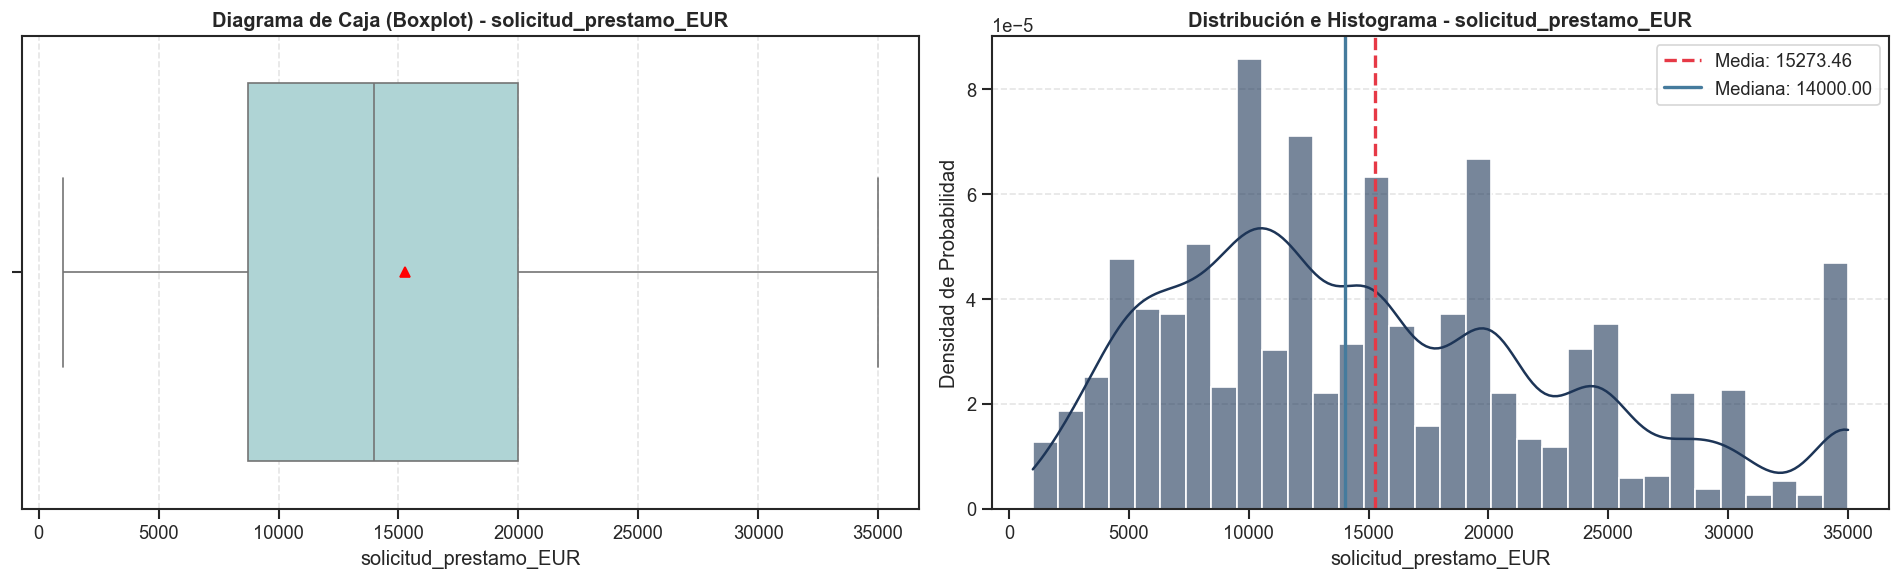

In [84]:
resumen = caracterizar_variable_numerica(
    datos=datos_pandas,
    variable=columnas_numericas[0]
)
resumen_variables.append(resumen)

---
---

##### 📌 Conclusiones de la variable: `solicitud_prestamo_EUR`

A partir de la caracterización estadística realizada, es posible derivar una serie de conclusiones relevantes sobre el comportamiento, la calidad y la estructura de la variable analizada.

---

🔹 1. Calidad de los datos

La variable presenta un **5% de valores ausentes**, lo cual indica un nivel de incompletitud relativamente bajo. 

- Este porcentaje sugiere que la información disponible es mayoritariamente confiable, aunque no despreciable desde el punto de vista analítico.

Dado este nivel de faltantes, es viable aplicar estrategias de imputación sin comprometer de forma significativa la representatividad de la variable. 

* Métodos simples como la mediana podrían ser suficientes en una primera aproximación. 

* La elección final del método de imputación dependerá del contexto de los datos y el estudio a desarrollar.

---

🔹 2. Estructura y diversidad de la variable

Se observa un total de **885 valores únicos**, lo que representa aproximadamente un **8.85% de cardinalidad relativa**. 

- Este resultado indica que la variable posee una **diversidad moderada**, compatible con su naturaleza cuantitativa.

No obstante, la baja proporción de valores únicos sugiere que la variable podría presentar cierto grado de agrupamiento en rangos específicos de valores de préstamo. 

* Consistente con estructuras típicas de productos financieros estandarizados.

---

🔹 3. Tendencia central y sesgo de la distribución

La media (15 273.46 EUR) es ligeramente superior a la mediana (14 000 EUR)

- Presencia de una **asimetría positiva** en la distribución.

Este comportamiento sugiere que existen algunos valores relativamente altos que están desplazando la media hacia la derecha, aunque sin generar una distorsión extrema del centro de la distribución. 

* En este caso, la mediana constituye una medida más robusta del valor típico de la variable.

---

🔹 4. Rango y valores extremos

La variable se encuentra acotada entre **1 000 EUR y 35 000 EUR**, sin presencia de valores negativos ni ceros. 

- Coherente con la naturaleza del fenómeno analizado (solicitudes de préstamo).

La ausencia de valores nulos estructurales en este sentido refuerza la consistencia del dominio de la variable y su interpretación financiera.

---

🔹 5. Dispersión y heterogeneidad

El **coeficiente de variación de 55.83%** indica una **dispersión alta o considerable**, lo cual evidencia una variabilidad importante entre los montos solicitados.

Este resultado implica que la variable no puede ser adecuadamente representada únicamente por su media, ya que existe una heterogeneidad significativa en los valores observados. 

* Sugiere la existencia de distintos perfiles de solicitantes con comportamientos financieros diferenciados.

---

🔹 6. Forma de la distribución

La distribución presenta una **asimetría positiva moderada (0.6290)**, lo que confirma la presencia de una cola hacia valores altos. 

- Comportamiento es típico en variables financieras, donde un subconjunto de usuarios solicita montos considerablemente mayores al promedio.

Por otro lado, la **curtosis negativa (-0.3606)** indica una distribución ligeramente platicúrtica, es decir, más achatada que una distribución normal, con menor concentración central y una dispersión más uniforme de los valores.

---

📊 7. Interpretación global

En conjunto, la variable `solicitud_prestamo_EUR` puede describirse como una variable:

- **Relativamente bien estructurada y completa**, con un nivel bajo de datos faltantes.
- **Altamente heterogénea**, con dispersión considerable.
- **Levemente asimétrica hacia valores altos**, lo que es consistente con la presencia de préstamos de mayor cuantía en una minoría de casos.
- **Sin valores anómalos extremos evidentes según la regla de Tukey**, lo que sugiere una distribución contenida dentro de rangos operativos razonables.

---

📌 Conclusión final

Desde una perspectiva analítica, esta variable es **altamente informativa para modelos predictivos**, pero requiere especial atención en la gestión de su alta variabilidad. 

La heterogeneidad observada sugiere que podría beneficiarse de transformaciones (por ejemplo, logarítmicas) o de segmentación previa, dependiendo del objetivo del análisis.

En general, se trata de una variable **consistente**, con **comportamiento típico** de variables financieras de demanda, donde predominan **distribuciones sesgadas y dispersas**, pero **sin anomalías estructurales críticas**.

---
---

#### **Variable: Aceptación Préstamo EUR**

Caracterización de variable: aceptacion_prestamo_EUR
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 889
  • Proporción de valores únicos: 8.89 %

🔹 Tendencia central
  • Media: 15311.0421
  • Mediana: 14000.0000

🔹 Valores extremos
  • Máximo valor: 35000.0000
  • Mínimo valor: 1000.0000
  • Cantidad ceros: 0
  • Cantidad negativos: 0

🔹 Medidas de Posición
  • Q1 (25%): 8800.0000
  • Q3 (75%): 20000.0000
  • Cantidad Outliers: 0

🔹 Medidas de Dispersión
  • Desviación estándar: 8531.9895
  • Coeficiente de Variación: 55.72 %
    Interpretación: Dispersión alta o considerable

🔹 Forma de la distribución
  • Asimetría (skewness): 0.6280
    Interpretación: Sesgo a la derecha (asimetría positiva)

  • Coeficiente curtosis: -0.3598
    Interpretación: Distribución de transición con tendencia platicúrtica (ligero achatamiento)

🎨 Generando gráficos informativos...


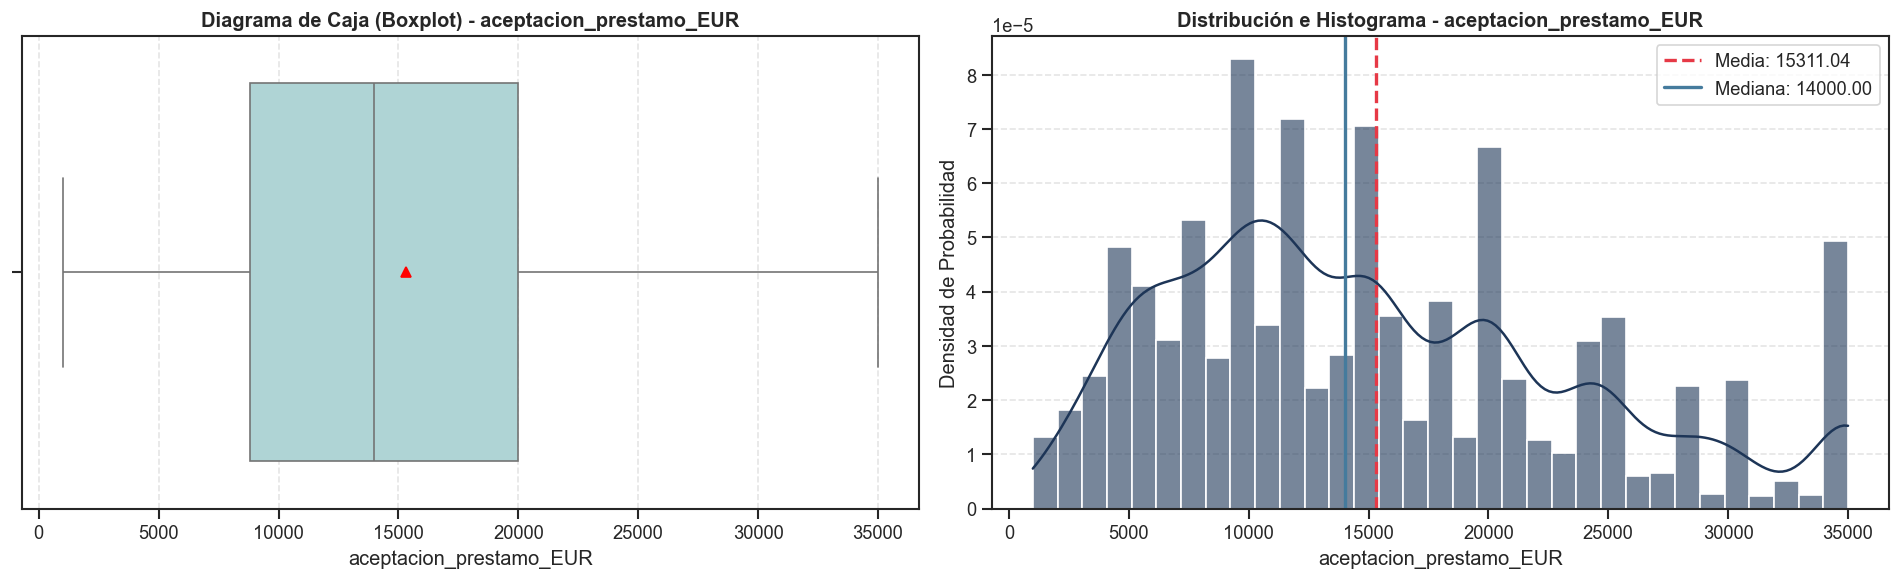

In [85]:
resumen = caracterizar_variable_numerica(
    datos=datos_pandas,
    variable=columnas_numericas[1]
)
resumen_variables.append(resumen)

---
---

##### 📌 Conclusiones de la variable: `solicitud_prestamo_EUR`

A partir de la caracterización estadística realizada, es posible derivar una serie de conclusiones relevantes sobre el comportamiento, la calidad y la estructura de la variable analizada.

---

🔹 1. Calidad de los datos

La variable presenta un **5% de valores ausentes**, lo cual indica un nivel de incompletitud relativamente bajo. 

- Este porcentaje sugiere que la información disponible es mayoritariamente confiable, aunque no despreciable desde el punto de vista analítico.

Dado este nivel de faltantes, es viable aplicar estrategias de imputación sin comprometer de forma significativa la representatividad de la variable. 

* Métodos simples como la mediana podrían ser suficientes en una primera aproximación. 

* La elección final del método de imputación dependerá del contexto de los datos y el estudio a desarrollar.

---

🔹 2. Estructura y diversidad de la variable

Se observa un total de **885 valores únicos**, lo que representa aproximadamente un **8.85% de cardinalidad relativa**. 

- Este resultado indica que la variable posee una **diversidad moderada**, compatible con su naturaleza cuantitativa.

No obstante, la baja proporción de valores únicos sugiere que la variable podría presentar cierto grado de agrupamiento en rangos específicos de valores de préstamo. 

* Consistente con estructuras típicas de productos financieros estandarizados.

---

🔹 3. Tendencia central y sesgo de la distribución

La media (15 273.46 EUR) es ligeramente superior a la mediana (14 000 EUR)

- Presencia de una **asimetría positiva** en la distribución.

Este comportamiento sugiere que existen algunos valores relativamente altos que están desplazando la media hacia la derecha, aunque sin generar una distorsión extrema del centro de la distribución. 

* En este caso, la mediana constituye una medida más robusta del valor típico de la variable.

---

🔹 4. Rango y valores extremos

La variable se encuentra acotada entre **1 000 EUR y 35 000 EUR**, sin presencia de valores negativos ni ceros. 

- Coherente con la naturaleza del fenómeno analizado (solicitudes de préstamo).

La ausencia de valores nulos estructurales en este sentido refuerza la consistencia del dominio de la variable y su interpretación financiera.

---

🔹 5. Dispersión y heterogeneidad

El **coeficiente de variación de 55.83%** indica una **dispersión alta o considerable**, lo cual evidencia una variabilidad importante entre los montos solicitados.

Este resultado implica que la variable no puede ser adecuadamente representada únicamente por su media, ya que existe una heterogeneidad significativa en los valores observados. 

* Sugiere la existencia de distintos perfiles de solicitantes con comportamientos financieros diferenciados.

---

🔹 6. Forma de la distribución

La distribución presenta una **asimetría positiva moderada (0.6290)**, lo que confirma la presencia de una cola hacia valores altos. 

- Comportamiento es típico en variables financieras, donde un subconjunto de usuarios solicita montos considerablemente mayores al promedio.

Por otro lado, la **curtosis negativa (-0.3606)** indica una distribución ligeramente platicúrtica, es decir, más achatada que una distribución normal, con menor concentración central y una dispersión más uniforme de los valores.

---

📊 7. Interpretación global

En conjunto, la variable `solicitud_prestamo_EUR` puede describirse como una variable:

- **Relativamente bien estructurada y completa**, con un nivel bajo de datos faltantes.
- **Altamente heterogénea**, con dispersión considerable.
- **Levemente asimétrica hacia valores altos**, lo que es consistente con la presencia de préstamos de mayor cuantía en una minoría de casos.
- **Sin valores anómalos extremos evidentes según la regla de Tukey**, lo que sugiere una distribución contenida dentro de rangos operativos razonables.

---

📌 Conclusión final

Desde una perspectiva analítica, esta variable es **altamente informativa para modelos predictivos**, pero requiere especial atención en la gestión de su alta variabilidad. 

La heterogeneidad observada sugiere que podría beneficiarse de transformaciones (por ejemplo, logarítmicas) o de segmentación previa, dependiendo del objetivo del análisis.

En general, se trata de una variable **consistente**, con **comportamiento típico** de variables financieras de demanda, donde predominan **distribuciones sesgadas y dispersas**, pero **sin anomalías estructurales críticas**.

---
---

#### **Variable: Razón Intereses**

Caracterización de variable: razon_intereses
🔹 Calidad de datos
  • Valores ausentes: 6004
  • Proporción de valores ausentes: 60.04 %

🔹 Diversidad de valores
  • Valores únicos: 59
  • Proporción de valores únicos: 0.59 %

🔹 Tendencia central
  • Media: 16.6173
  • Mediana: 16.2400

🔹 Valores extremos
  • Máximo valor: 28.9900
  • Mínimo valor: 6.0000
  • Cantidad ceros: 0
  • Cantidad negativos: 0

🔹 Medidas de Posición
  • Q1 (25%): 13.9900
  • Q3 (75%): 18.2500
  • Cantidad Outliers: 92
  • Proporción de Outliers: 0.92 %

🔹 Medidas de Dispersión
  • Desviación estándar: 2.9572
  • Coeficiente de Variación: 17.8 %
    Interpretación: Dispersión moderada

🔹 Forma de la distribución
  • Asimetría (skewness): 1.0691
    Interpretación: Sesgo a la derecha (asimetría positiva)

  • Coeficiente curtosis: 1.1088
    Interpretación: Distribución leptocúrtica (curva puntiaguda con colas pesadas)

🎨 Generando gráficos informativos...


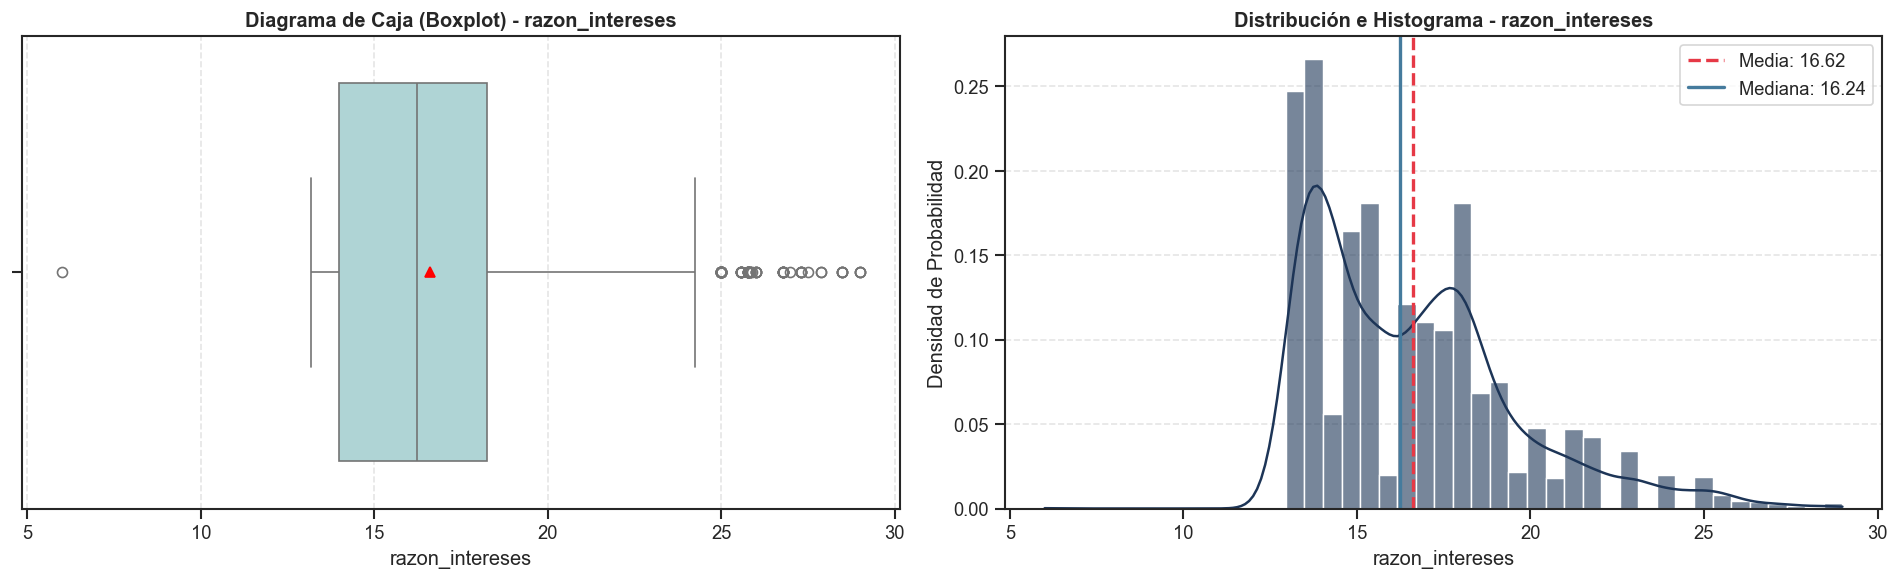

In [86]:
resumen = caracterizar_variable_numerica(
    datos=datos_pandas,
    variable=columnas_numericas[2]
)
resumen_variables.append(resumen)

---
---

##### 📌 Reporte Descriptivo: variable `razon_intereses`

El análisis estadístico y visual describe el comportamiento de las tasas o razones de interés aplicadas en el conjunto de datos. 

A grandes rasgos, la variable se caracteriza por presentar una **pérdida crítica de información (más de la mitad de los datos ausentes)**, una **dispersión moderada y homogénea**, un **sesgo marcado hacia valores altos** y la **presencia formal de anomalías estadísticamente significativas (*outliers*)** en ambos extremos de la distribución.

---

##### 1. Calidad y Diversidad de los Datos
* **Valores Faltantes:** Se detectaron **6,004 valores nulos**, lo que representa un alarmante **60.04%** del total de la muestra. 
  * *Significado práctico:* La variable se encuentra en un estado crítico. Una ausencia de datos tan severa invalida por completo cualquier intento de imputación simple (como usar la media o la mediana), ya que destruiría la distribución real. Se requiere una auditoría profunda para entender si el dato falta por un error de registro o si responde a una ausencia condicionada (ej. registros de clientes sin historial crediticio previo).
* **Diversidad:** Cuenta con **59 valores únicos** (**0.59%** de representatividad), lo que indica que a pesar de ser una escala continua, los intereses tienden a agruparse en tasas nominales o puntos porcentuales fijos y estandarizados por la institución.

---

##### 2. Tendencia Central y Forma (Sesgo)
* **Media aritmética:** 16.62 %
* **Mediana (Q2):** 16.24 %
* **Asimetría (Skewness):** 1.0691 $\rightarrow$ **Sesgo marcado a la derecha (asimetría positiva)**

**Interpretación analítica:** El coeficiente de asimetría supera la frontera crítica de 1.0, diagnosticando un sesgo fuerte y pronunciado. Aunque la mitad de las tasas se concentran por debajo del 16.24% (mediana), existe una "cola" muy extendida hacia la derecha conformada por tasas de interés considerablemente altas que arrastran de forma agresiva a la media aritmética hacia arriba.

---

##### 3. Medidas de Posición y Dispersión
* **Rango Operativo:** Desde un mínimo de **6.00 %** hasta un máximo de **28.99 %**.
* **Rango Intercuartílico (IQR):** **4.26 %**, el cual delimita la franja del 50% central del mercado:
  * **Percentil 25 (Q1):** 13.99 % $\rightarrow$ El 25% de los registros goza de tasas preferenciales o bajas, menores o iguales a este valor.
  * **Percentil 75 (Q3):** 18.25 % $\rightarrow$ El 75% de la población cuenta con tasas por debajo de esta cifra; el 25% restante asume las tasas más caras del portafolio.
* **Variabilidad Absoluta:** La varianza de $8.74$ equivale a una desviación estándar de **2.96 %**, confirmando que la mayoría de los intereses oscilan de forma estrecha alrededor de la media.
* **Variabilidad Relativa:** El **Coeficiente de Variación (CV)** se ubica en **17.80%** $\rightarrow$ **Dispersión moderada**. A diferencia de los montos de los préstamos, el comportamiento de las tasas es notablemente más estable, homogéneo y controlado internamente.

---

##### 4. Diagnóstico de Anomalías (Outliers)
Aplicando la Regla de Tukey con un factor de multiplicación de 1.5 sobre el IQR, se establecieron las siguientes fronteras estadísticas de normalidad:
* **Límite Inferior Teórico:** 7.60 %
* **Límite Superior Teórico:** 24.64 %

**Resultado del diagnóstico:** Se detectaron **92 valores atípicos (*outliers*)**, correspondientes al **0.92%** de la muestra total. 
  * *Interpretación analítica:* Dado que el valor mínimo registrado (**6.00%**) está por debajo del límite inferior (7.60%), existen clientes con tasas de interés excepcionalmente bajas (beneficios especiales o perfiles de riesgo mínimo). Del mismo modo, como el valor máximo (**28.99%**) supera la frontera superior (24.64%), se identifica un grupo que está pagando penalizaciones o tasas de usura fuera de la norma estadística. El gráfico de caja (*boxplot*) reflejará estos 92 registros como puntos aislados fuera de ambos bigotes.

---

##### 🔍 Conclusión Técnica para el EDA
Esta variable presenta un doble desafío para la ingeniería de características (*feature engineering*):
1. **Tratamiento de Nulos:** Con un 60.04% de NaN, la variable no puede usarse directamente en modelos de Machine Learning. Se sugiere evaluar la creación de una variable indicadora binaria (`tiene_razon_interes`: 0 o 1) o recurrir a una imputación avanzada basada en modelos predictivos (como *Random Forest Regressor*) correlacionando la tasa con el nivel de riesgo (`grade` / `sub_grade`).
2. **Mitigación de Outliers:** Al existir anomalías en ambos extremos y un skew superior a 1.0, los modelos lineales sufrirán grandes distorsiones. Si se decide rescatar la variable, será estrictamente necesario aplicar una **transformación matemática fuerte** (como el logaritmo natural) o un recorte de valores extremos mediante winsorización antes del entrenamiento.

---
---

#### **Variable: Pago Mensual**

Caracterización de variable: pago_mensual_EUR
🔹 Calidad de datos
  • Valores ausentes: 501
  • Proporción de valores ausentes: 5.01 %

🔹 Diversidad de valores
  • Valores únicos: 4337
  • Proporción de valores únicos: 43.37 %

🔹 Tendencia central
  • Media: 440.9222
  • Mediana: 385.3400

🔹 Valores extremos
  • Máximo valor: 1372.9700
  • Mínimo valor: 31.4200
  • Cantidad ceros: 0
  • Cantidad negativos: 0

🔹 Medidas de Posición
  • Q1 (25%): 267.2300
  • Q3 (75%): 576.0300
  • Cantidad Outliers: 260
  • Proporción de Outliers: 2.6 %

🔹 Medidas de Dispersión
  • Desviación estándar: 241.3556
  • Coeficiente de Variación: 54.74 %
    Interpretación: Dispersión alta o considerable

🔹 Forma de la distribución
  • Asimetría (skewness): 0.9391
    Interpretación: Sesgo a la derecha (asimetría positiva)

  • Coeficiente curtosis: 0.6728
    Interpretación: Distribución leptocúrtica (curva puntiaguda con colas pesadas)

🎨 Generando gráficos informativos...


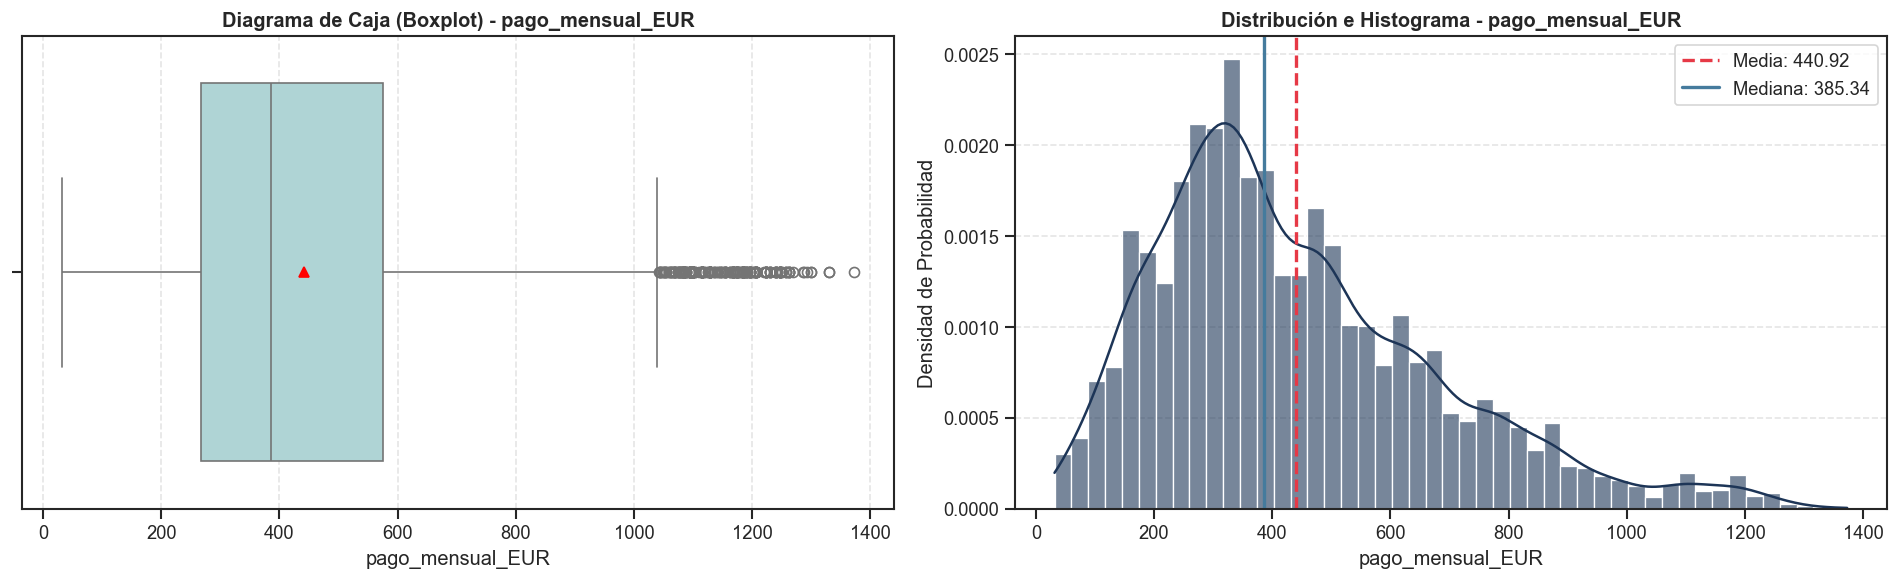

In [87]:
resumen = caracterizar_variable_numerica(
    datos=datos_pandas,
    variable=columnas_numericas[3]
)
resumen_variables.append(resumen)

---
---

##### 📌 Reporte Descriptivo: variable `pago_mensual_EUR`

El análisis estadístico y visual describe el comportamiento de las cuotas de pago mensual fijadas en euros para los préstamos del portafolio.

A grandes rasgos, la variable se caracteriza por una **dispersión alta y heterogénea**, un **sesgo positivo hacia cuotas elevadas**, una **fuerte concentración en torno a la zona media-baja (estructura leptocúrtica)** y la **presencia formal de valores atípicos (*outliers*)** concentrados exclusivamente en el extremo superior.

---

##### 1. Calidad y Diversidad de los Datos
* **Valores Faltantes:** Se detectaron **501 valores nulos**, lo que representa el **5.01%** del total de la muestra. Es un volumen bajo que sugiere una pérdida menor de información; se recomienda una imputación robusta por mediana antes de alimentar modelos predictivos.
* **Diversidad:** Cuenta con **4,337 valores únicos** (**43.37%** de representatividad), un indicador sumamente alto que confirma una granularidad fina y el comportamiento clásico de una variable cuantitativa continua altamente dinámica.

---

##### 2. Tendencia Central y Forma (Sesgo y Curtosis)
* **Media aritmética:** 440.92 EUR
* **Mediana (Q2):** 385.34 EUR
* **Asimetría (Skewness):** 0.9391 $\rightarrow$ **Sesgo a la derecha (asimetría positiva)**
* **Curtosis:** 0.9391 $\rightarrow$ **Distribución Leptocúrtica (curva puntiaguda con colas pesadas)**

**Interpretación analítica:** La media se encuentra notablemente desplazada por encima de la mediana, confirmando un sesgo positivo marcado. El histograma y la curva **KDE** reflejarán una acumulación masiva de registros en cuotas bajas y moderadas (cuyo punto máximo o "pico" destaca con fuerza debido a la estructura leptocúrtica), combinada con una "cola pesada" que se extiende hacia la derecha. Esto demuestra que la gran mayoría de los clientes pagan cuotas mensuales inferiores a los 400 EUR, pero un grupo selecto asume compromisos mensuales muy elevados que empujan el promedio general al alza.

---

##### 3. Medidas de Posición y Dispersión
* **Rango Operativo:** Desde una cuota mínima de **31.42 EUR** hasta un máximo de **1,372.97 EUR**.
* **Rango Intercuartílico (IQR):** **308.80 EUR**, el cual delimita la concentración del 50% central de los datos:
  * **Percentil 25 (Q1):** 267.23 EUR $\rightarrow$ El 25% de la población paga cuotas muy bajas, inferiores o iguales a esta cifra.
  * **Percentil 75 (Q3):** 576.03 EUR $\rightarrow$ El 75% de la población paga mensualidades por debajo de esta cifra.
* **Variabilidad Absoluta:** La varianza de $58,252.51$ equivale a una desviación estándar de **241.36 EUR**, reflejando que los pagos mensuales se apartan significativamente de la media.
* **Variabilidad Relativa:** El **Coeficiente de Variación (CV)** se sitúa en **54.74%** $\rightarrow$ **Dispersión alta o considerable**. Al igual que los montos solicitados, las cuotas mensuales presentan una estructura heterogénea que confirma perfiles financieros muy diversos dentro del mismo portafolio.

---

##### 4. Diagnóstico de Anomalías (Outliers)
Aplicando la Regla de Tukey con un factor de multiplicación de 1.5 sobre el IQR, se establecieron las siguientes fronteras estadísticas de control:
* **Límite Inferior Teórico:** -195.97 EUR (fijado operativamente en 31.42 EUR dado que no existen pagos negativos).
* **Límite Superior Teórico:** 1,039.23 EUR

**Resultado del diagnóstico:** Se detectaron **260 valores atípicos (*outliers*)**, que representan el **2.6%** de la muestra total.
  * *Interpretación analítica:* Dado que el valor máximo registrado (**1,372.97 EUR**) supera el umbral del límite superior (1,039.23 EUR), se identifica un segmento de clientes con obligaciones mensuales excepcionalmente agresivas. El gráfico de caja (*boxplot*) mostrará una densidad importante de puntos suspendidos en el extremo derecho, representando un nicho de alto valor (y potencialmente mayor riesgo de impago) que rompe con la pauta estadística general del portafolio.

---

##### 🔍 Conclusión Técnica para el EDA
Esta variable refleja de manera directa el impacto de los montos de préstamos grandes analizados previamente. Para el tratamiento de datos y preparación de modelos de Machine Learning, se derivan dos acciones clave:
1. **Mitigación del Sesgo y Anomalías:** Al presentar un skew cercano a 1.0 y un 2.6% de outliers superiores, los algoritmos basados en optimización por gradiente o distancias (como regresiones, SVM o redes neuronales) sufrirán distorsiones en sus fronteras de decisión. Es altamente recomendable aplicar una **transformación logarítmica (`np.log1p`)** para suavizar la cola pesada y estabilizar la curtosis.
2. **Imputación Coherente:** El 5.01% de registros nulos debe ser corregido mediante la **mediana** para proteger la distribución de la influencia de las cuotas extremas superiores.

---
---

#### **Variable: Pago Efectuado**

Caracterización de variable: pago_efectuado_EUR
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 8224
  • Proporción de valores únicos: 82.24 %

🔹 Tendencia central
  • Media: 3143.8509
  • Mediana: 1973.7050

🔹 Valores extremos
  • Máximo valor: 41913.6200
  • Mínimo valor: 0.0000
  • Cantidad ceros: 384
  • Proporción ceros: 3.84 %
  • Cantidad negativos: 0

🔹 Medidas de Posición
  • Q1 (25%): 889.5925
  • Q3 (75%): 3765.2500
  • Cantidad Outliers: 645
  • Proporción de Outliers: 6.45 %

🔹 Medidas de Dispersión
  • Desviación estándar: 4222.3518
  • Coeficiente de Variación: 134.31 %
    Interpretación: Dispersión alta o considerable

🔹 Forma de la distribución
  • Asimetría (skewness): 4.1208
    Interpretación: Sesgo a la derecha (asimetría positiva)

  • Coeficiente curtosis: 23.0955
    Interpretación: Distribución leptocúrtica (curva puntiaguda con colas pesadas)

🎨 Generando gráficos informativos

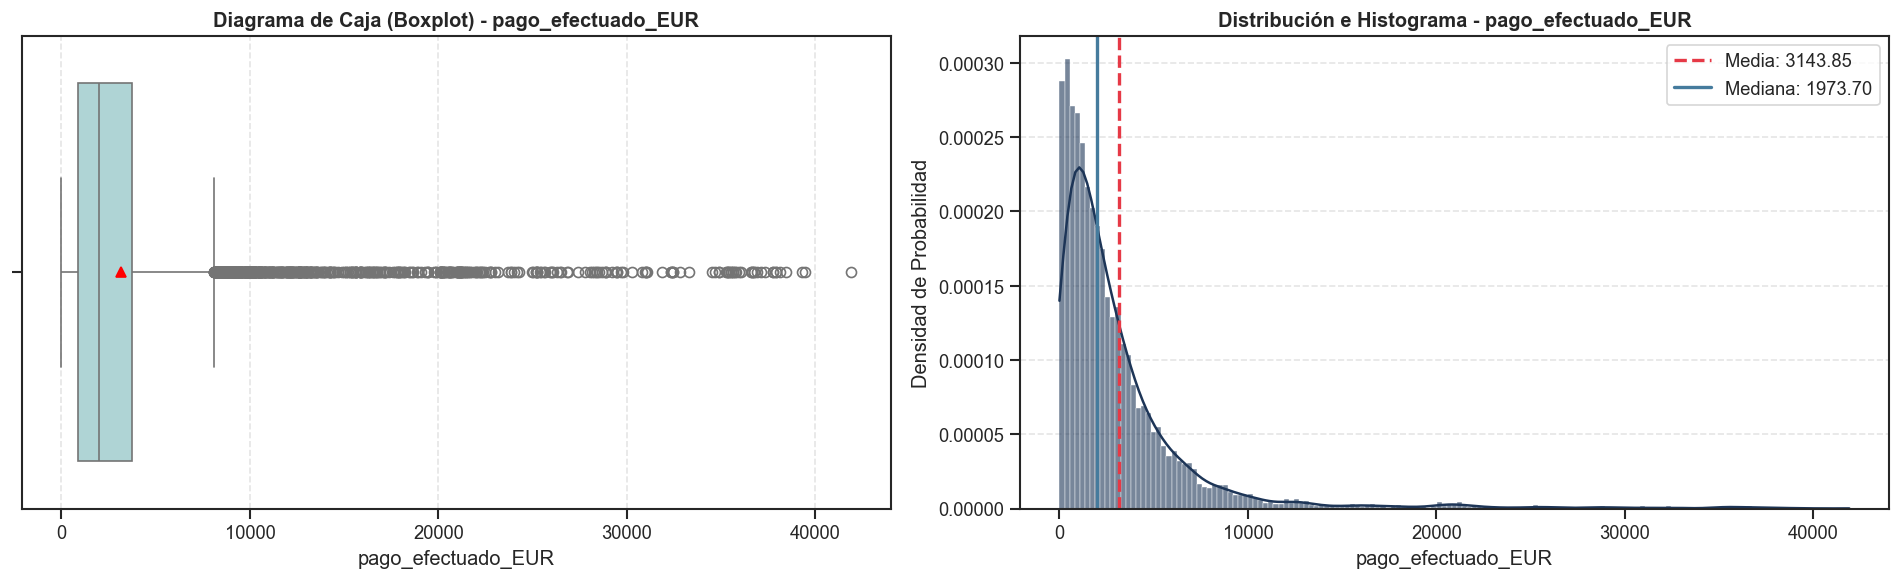

In [88]:
resumen = caracterizar_variable_numerica(
    datos=datos_pandas,
    variable=columnas_numericas[4]
)
resumen_variables.append(resumen)

---
---

##### 📌 Reporte Descriptivo: variable `pago_efectuado_EUR`

El análisis estadístico y visual describe el comportamiento de los montos totales ya pagados o efectuados en euros por los clientes del portafolio.

A grandes rasgos, la variable presenta una **dispersión masiva y críticamente heterogénea**, un **sesgo positivo severo y extremo**, una **concentración masiva en valores bajos con colas hiper-pesadas (leptocúrtica)** y una **presencia masiva de valores atípicos (*outliers*)** concentrados exclusivamente en la franja superior de la distribución.

---

##### 1. Calidad y Diversidad de los Datos
* **Valores Faltantes:** Se detectaron **500 valores nulos**, lo que representa el **5.0%** del total de la muestra. Es un volumen bajo y controlado; se recomienda una imputación por mediana para evitar que la severa deformación de la variable afecte el llenado de nulos.
* **Diversidad:** Cuenta con **8,224 valores únicos** (**82.24%** de representatividad), reflejando una granularidad e individualidad casi total en los registros, comportamiento clásico de montos acumulados dinámicamente a lo largo del tiempo.

---

##### 2. Tendencia Central y Forma (Sesgo y Curtosis)
* **Media aritmética:** 3,143.85 EUR
* **Mediana (Q2):** 1,973.71 EUR
* **Asimetría (Skewness):** 4.1208 $\rightarrow$ **Sesgo severo a la derecha (asimetría positiva extrema)**
* **Curtosis:** 4.1208 $\rightarrow$ **Distribución fuertemente Leptocúrtica (pico extremo con colas hiper-pesadas)**

**Interpretación analítica:** El coeficiente de asimetría rompe los umbrales estándar al superar el valor de 4.0. Físicamente, esto significa que la media está masivamente "arrastrada" hacia arriba por un grupo de registros con pagos acumulados gigantescos. La mediana de apenas 1,973.71 EUR nos dice que la mitad de la población ha efectuado pagos muy pequeños, pero la cola de la derecha se extiende de manera descomunal hasta superar los 41,000 EUR. Su naturaleza leptocúrtica extrema confirma que casi toda la población está confinada en la base inferior del gráfico, pero los pocos que escapan tienen valores exponencialmente altos.

---

##### 3. Medidas de Posición y Dispersión
* **Rango Operativo:** Desde un mínimo de **0.00 EUR** (usuarios que no han efectuado ningún pago) hasta un máximo histórico de **41,913.62 EUR**.
* **Rango Intercuartílico (IQR):** **2,875.66 EUR**, el cual delimita la concentración del 50% central de los datos:
  * **Percentil 25 (Q1):** 889.59 EUR $\rightarrow$ El 25% de la población ha efectuado pagos mínimos o muy iniciales por debajo de esta cifra.
  * **Percentil 75 (Q3):** 3,765.25 EUR $\rightarrow$ El 75% de la población mantiene pagos acumulados por debajo de este umbral.
* **Variabilidad Absoluta:** La varianza se dispara hasta los $17,828,254.33$, lo que equivale a una desviación estándar de **4,222.35 EUR**. Notablemente, ¡la desviación estándar es mucho mayor que la propia media!
* **Variabilidad Relativa:** El **Coeficiente de Variación (CV)** alcanza un alarmante **134.31%** $\rightarrow$ **Dispersión masiva y extrema**. Un $CV$ superior al 100% es el diagnóstico definitivo de una variable hiper-heterogénea, donde los datos varían de forma caótica entre sí y el concepto de "pago promedio" carece por completo de sentido operativo.

---

##### 4. Diagnóstico de Anomalías (Outliers)
Aplicando la Regla de Tukey con un factor de multiplicación de 1.5 sobre el IQR, se establecieron las siguientes fronteras estadísticas de control:
* **Límite Inferior Teórico:** -3,423.89 EUR (fijado operativamente en 0.00 EUR).
* **Límite Superior Teórico:** 8,078.74 EUR

**Resultado del diagnóstico:** Se detectaron **645 valores atípicos (*outliers*)**, que representan un masivo **6.45%** de la muestra total.
  * *Interpretación analítica:* Cualquier cliente que haya efectuado pagos superiores a los **8,078.74 EUR** rompe el patrón normal del portafolio. Dado que el máximo llega a más de 41k, estamos ante un volumen muy grande de anomalías superiores (645 registros). El diagrama de caja (*boxplot*) mostrará una línea de outliers densa, masiva y extremadamente larga que desfigurará la escala visual de la caja.

---

##### 🔍 Conclusión Técnica para el EDA
Esta variable se encuentra en un estado de deformación estadística crítico y **no puede ser utilizada de forma cruda** en casi ningún algoritmo de Machine Learning (especialmente en modelos lineales, de distancia o redes neuronales), ya que los 645 outliers y el skew de 4.12 monopolizarán las funciones de pérdida e invalidarán el aprendizaje.

**Acciones de Ingeniería de Características (Feature Engineering) Obligatorias:**
1. **Transformación Logarítmica Drástica:** Es estrictamente necesario aplicar una transformación de tipo `np.log1p(datos['pago_efectuado_EUR'])`. Esto comprimirá la escala de los valores extremos en el extremo derecho, reducirá el skew de >4 a rangos tolerables (<1) y transformará los outliers en registros manejables para la distribución.
2. **Segmentación:** Considerar la creación de una bandera binaria o categórica para aislar al segmento "High-Value" (> 8,078.74 EUR), ya que operativamente representan un comportamiento comercial completamente diferente al resto del portafolio.
3. **Imputación:** El 5% de nulos debe ser reemplazado única y exclusivamente por la **mediana**, ya que la media está severamente distorsionada por el sesgo.

---
---

#### **Variable: Meses Préstamo**

Caracterización de variable: meses_prestamo
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 2
  • Proporción de valores únicos: 0.02 %

🔹 Tendencia central
  • Media: 44.1322
  • Mediana: 36.0000

🔹 Valores extremos
  • Máximo valor: 60.0000
  • Mínimo valor: 36.0000
  • Cantidad ceros: 0
  • Cantidad negativos: 0

🔹 Medidas de Posición
  • Q1 (25%): 36.0000
  • Q3 (75%): 60.0000
  • Cantidad Outliers: 0

🔹 Medidas de Dispersión
  • Desviación estándar: 11.3602
  • Coeficiente de Variación: 25.74 %
    Interpretación: Dispersión moderada

🔹 Forma de la distribución
  • Asimetría (skewness): 0.6811
    Interpretación: Sesgo a la derecha (asimetría positiva)

  • Coeficiente curtosis: -1.5365
    Interpretación: Distribución platicúrtica (curva achatada o plana)

🎨 Generando gráficos informativos...


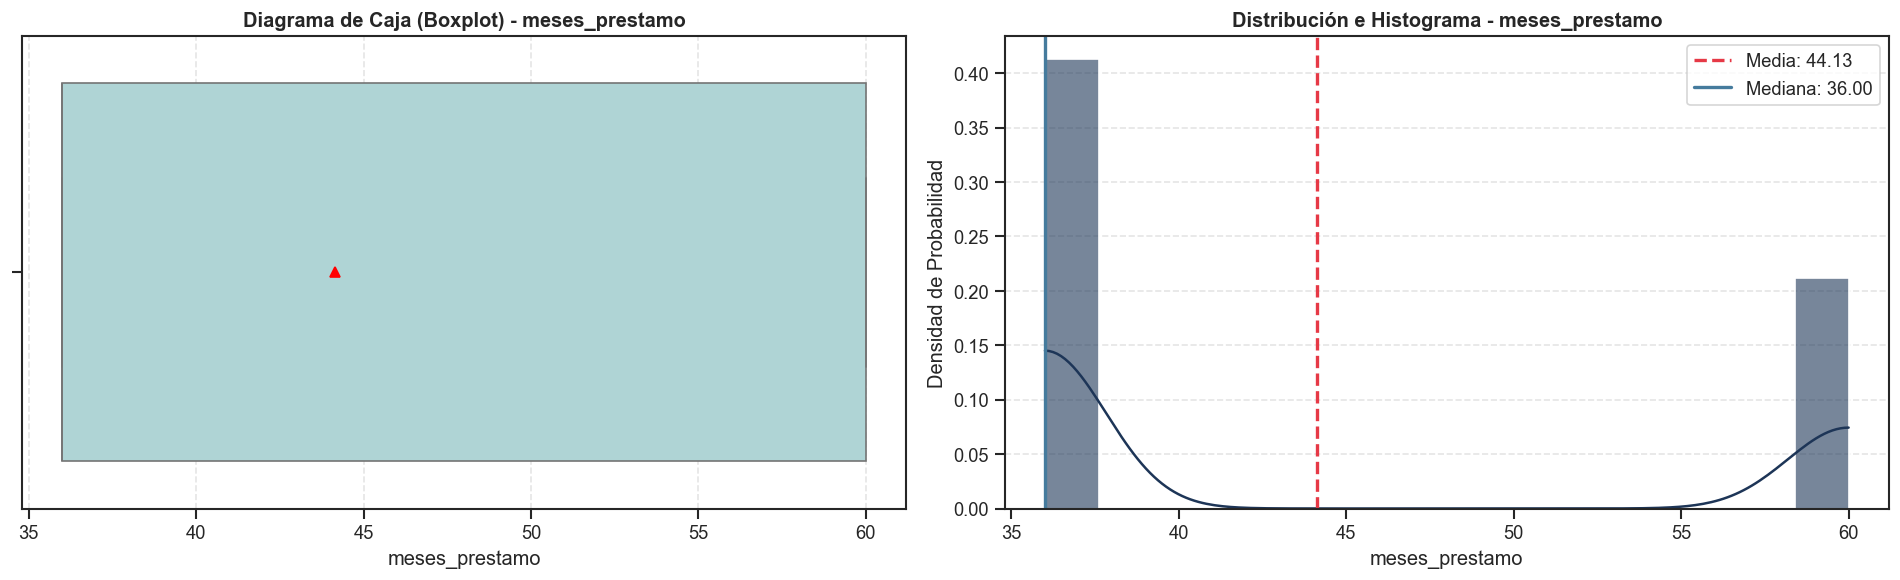

In [89]:
resumen = caracterizar_variable_numerica(
    datos=datos_pandas,
    variable=columnas_numericas[5]
)
resumen_variables.append(resumen)

---
---

##### 📌 Reporte Descriptivo: variable `meses_prestamo`

El análisis estadístico y visual describe el comportamiento de los plazos o duración de los créditos otorgados, expresados en meses.

A grandes rasgos, la variable se comporta como una **estructura discreta binaria de dos horizontes temporales**, presentando una **dispersión moderada**, un **sesgo hacia el plazo menor (36 meses)** y una **ausencia absoluta de valores atípicos (*outliers*)**.

---

##### 1. Calidad y Diversidad de los Datos
* **Valores Faltantes:** Se detectaron **500 valores nulos**, lo que representa el **5.0%** del total de la muestra. Es un volumen bajo y controlado; se recomienda una imputación por la moda o la mediana antes de alimentar modelos predictivos.
* **Diversidad:** Cuenta con únicamente **2 valores únicos** (**0.02%** de representatividad). 
  * *Significado práctico:* Este indicador es clave. Confirma que la variable no es continua, sino que el portafolio opera bajo dos únicos esquemas de financiamiento fijos (típicamente plazos estandarizados de 36 y 60 meses).

---

##### 2. Tendencia Central y Forma (Sesgo y Curtosis)
* **Media aritmética:** 44.13 meses
* **Mediana (Q2):** 36.00 meses
* **Asimetría (Skewness):** 0.6811 $\rightarrow$ **Sesgo a la derecha (asimetría positiva)**
* **Curtosis:** 0.6811 $\rightarrow$ **Distribución Platicúrtica (interpretada analíticamente como bimodal)**

**Interpretación analítica:** Dado que la variable solo toma los valores de 36 y 60, la media aritmética (44.13 meses) no representa un plazo real que un cliente pueda elegir, sino el centro de gravedad ponderado. Al estar la media más cerca de 36 que de 60, y coincidir la mediana exactamente en 36.00, se confirma el sesgo positivo. Esto nos dice matemáticamente que **el volumen de créditos a corto/mediano plazo (36 meses) es significativamente mayor** que el de largo plazo (60 meses). El histograma visualiza esto mediante dos barras aisladas donde la barra de los 36 meses es notablemente más alta.

---

##### 3. Medidas de Posición y Dispersión
* **Rango Operativo:** Delimitado estrictamente entre un mínimo de **36.00 meses** y un máximo de **60.00 meses**.
* **Rango Intercuartílico (IQR):** **24.00 meses**, la distancia exacta entre ambos extremos operativos:
  * **Percentil 25 (Q1):** 36.00 meses $\rightarrow$ Al menos el 25% (y de hecho, la mayoría de la población) se concentra en el límite inferior.
  * **Percentil 75 (Q3):** 60.00 meses $\rightarrow$ El tercer cuartil alcanza la frontera del plazo largo.
* **Variabilidad Absoluta:** La varianza de $129.05$ equivale a una desviación estándar de **11.36 meses**, cuantificando la oscilación promedio entre las dos únicas opciones disponibles.
* **Variabilidad Relativa:** El **Coeficiente de Variación (CV)** se ubica en **25.74%** $\rightarrow$ **Dispersión moderada**. La dispersión está acotada y controlada debido a la ausencia de un espectro continuo de valores o de plazos intermedios (como 12, 24 o 48 meses).

---

##### 4. Diagnóstico de Anomalías (Outliers)
Aplicando la Regla de Tukey con un factor de multiplicación de 1.5 sobre el IQR, se establecieron las siguientes fronteras teóricas de control:
* **Límite Inferior Teórico:** 0.00 meses
* **Límite Superior Teórico:** 96.00 meses

**Resultado del diagnóstico:** La **Cantidad de Outliers detectados es 0**. Dado que las dos únicas opciones existentes (36 y 60 meses) se encuentran perfectamente contenidas dentro de las fronteras teóricas de la regla de Tukey, no existe ningún registro anómalo. El gráfico de caja (*boxplot*) reflejará una estructura particular: una caja ensanchada que toca ambos extremos operativos, sin puntos suspendidos más allá de los límites.

---

##### 🔍 Conclusión Técnica para el EDA
El diagnóstico analítico de `meses_prestamo` altera la estrategia de preparación de datos en comparación con el resto de las variables numéricas:
1. **Naturaleza de la Variable:** A pesar de estar codificada numéricamente, su baja cardinalidad (2 valores únicos) sugiere que para ciertos modelos (como árboles de decisión o ensamblados) puede tratarse directamente como una **variable categórica binaria u ordinal**. 
2. **Imputación:** El 5.0% de registros nulos debe ser reemplazado por la **mediana (36.00)** o la moda, lo cual garantiza que el valor imputado sea una opción de plazo real y válida para el negocio.
3. **Modelado:** Al no poseer outliers ni un comportamiento continuo real, esta variable no requiere de transformaciones matemáticas de escala (como logaritmos o estandarizaciones), quedando lista para actuar como una excelente característica de segmentación temporal.

---
---

#### **Resumen Variables Numéricas**

In [90]:
resumen_numerico_pandas = pd.DataFrame(resumen_variables)
resumen_numerico_pandas.set_index("variable", inplace=True)

resumen_numerico_pandas.to_csv('metricas_variables_numericas.csv')
resumen_numerico_pandas.head()

,cantidad_datos,cantidad_ausentes,proporcion_ausentes,cantidad_unicos,proporcion_unicos,promedio,mediana,maximo,minimo,cantidad_ceros,...,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers,proporcion_outliers,desviacion_estandar,coeficiente_variacion,curtosis,skew
variable,,,,,,,,,,,,,,,,,,,,,
solicitud_prestamo_EUR,10000,500,5.00,885,8.85,15273.463158,14000.000,35000.00,1000.00,0,...,20000.00,11256.2500,-8140.62500,36884.37500,0,0.00,8527.234720,55.83,-0.360647,0.628988
aceptacion_prestamo_EUR,10000,500,5.00,889,8.89,15311.042105,14000.000,35000.00,1000.00,0,...,20000.00,11200.0000,-8000.00000,36800.00000,0,0.00,8531.989496,55.72,-0.359761,0.627985
razon_intereses,10000,6004,60.04,59,0.59,16.617295,16.240,28.99,6.00,0,...,18.25,4.2600,7.60000,24.64000,92,0.92,2.957174,17.80,1.108830,1.069081
pago_mensual_EUR,10000,501,5.01,4337,43.37,440.922179,385.340,1372.97,31.42,0,...,576.03,308.8000,-195.97000,1039.23000,260,2.60,241.355569,54.74,0.672841,0.939075
pago_efectuado_EUR,10000,500,5.00,8224,82.24,3143.850941,1973.705,41913.62,0.00,384,...,3765.25,2875.6575,-3423.89375,8078.73625,645,6.45,4222.351754,134.31,23.095543,4.120772


___
___



### Análisis Individual de Variables Categóricas

In [91]:
resumen_categorias = []
datos_pandas[columnas_no_numericas].head()

,identificador,fecha_prestamo,estado_prestamo,grado,sub_grado,estado_verificacion,estado
0,48010226,1-05-15,Current,C,C3,Verified,CA
1,57693261,NaT,Current,A,A5,Source Verified,NY
2,59432726,1-09-15,Current,B,B5,Verified,PA
3,53222800,1-07-15,Current,A,A5,Not Verified,OH
4,57803010,1-08-15,Current,NaN,E3,Source Verified,TX


#### **Variable: Fecha Préstamo**

In [92]:
datos_pandas_modificado = pd.DataFrame()
datos_pandas_modificado[columnas_no_numericas[1]] = datos_pandas[columnas_no_numericas[1]].dt.strftime('%b')
datos_pandas_modificado.head()

,fecha_prestamo
0,May
1,NaN
2,Sep
3,Jul
4,Aug


Caracterización de variable: fecha_prestamo
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 12
  • Proporción de valores únicos: 0.12 %
  • Entropía de Shannon (normalizada): 0.9899
  • Número efectivo de categorías: 11.70

🔹 Medidas de Concentración y Dominancia
  • Moda: Oct
  • Antimodal: Feb
  • Frecuencia de la Moda: 1095.0000
  • Proporción de la máxima frecuencia: 10.95 %
  • Frecuencia del Antimodal: 530.0000
  • Proporción de la mínima frecuencia: 5.3 %
  • Índice de dominancia extrema: 2.07
  • Índice de dominancia global: 0.12

🔹 Balance de las categorías
  • Coeficiente de variación de las frecuencias: 23.5 %
     - Existe cierto desbalance entre categorías, aunque ninguna domina claramente.
  • Índice de Simpson: 0.0876
  • Mínimo Teórico del Índice de Simpson: 0.0833
  • Índice Normalizado de Simpson: 0.4691 %
  • Coeficiente de uniformidad: 0.9752
     - Distribución muy uniforme

🔹 Categ

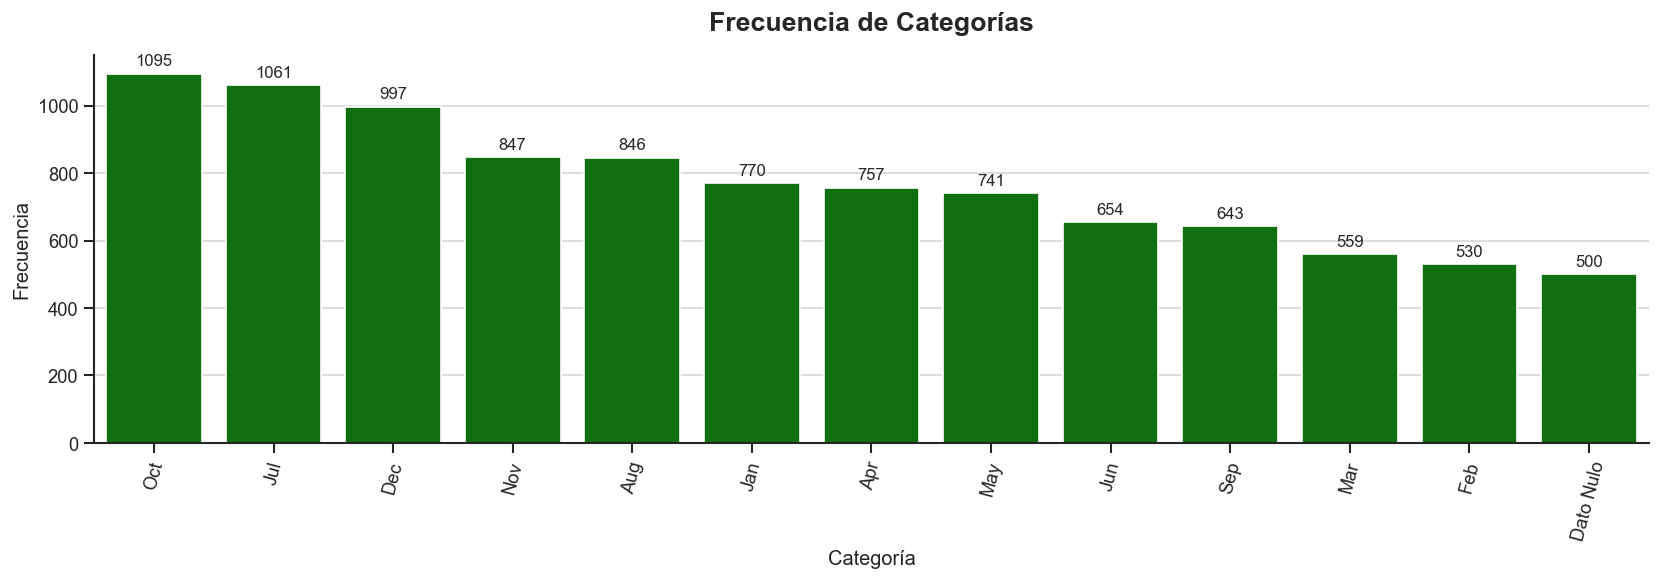

In [291]:
resumen = caracterizar_variable_no_numerica(
    datos=datos_pandas_modificado,
    variable=columnas_no_numericas[1]
)
resumen_categorias.append(resumen)

#### **Variable: Estado Préstamo**

Caracterización de variable: estado_prestamo
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 8
  • Proporción de valores únicos: 0.08 %
  • Entropía de Shannon (normalizada): 0.2262
  • Número efectivo de categorías: 1.60

🔹 Medidas de Concentración y Dominancia
  • Moda: Current
  • Antimodal: Default
  • Frecuencia de la Moda: 8538.0000
  • Proporción de la máxima frecuencia: 85.38 %
  • Frecuencia del Antimodal: 11.0000
  • Proporción de la mínima frecuencia: 0.11 %
  • Índice de dominancia extrema: 776.18
  • Índice de dominancia global: 5.84

🔹 Balance de las categorías
  • Coeficiente de variación de las frecuencias: 250.47 %
     - La distribución presenta un desbalance importante y una o pocas categorías concentran la mayor parte de las observaciones
  • Índice de Simpson: 0.8112
  • Mínimo Teórico del Índice de Simpson: 0.125
  • Índice Normalizado de Simpson: 78.4229 %
  • Coeficiente de unifo

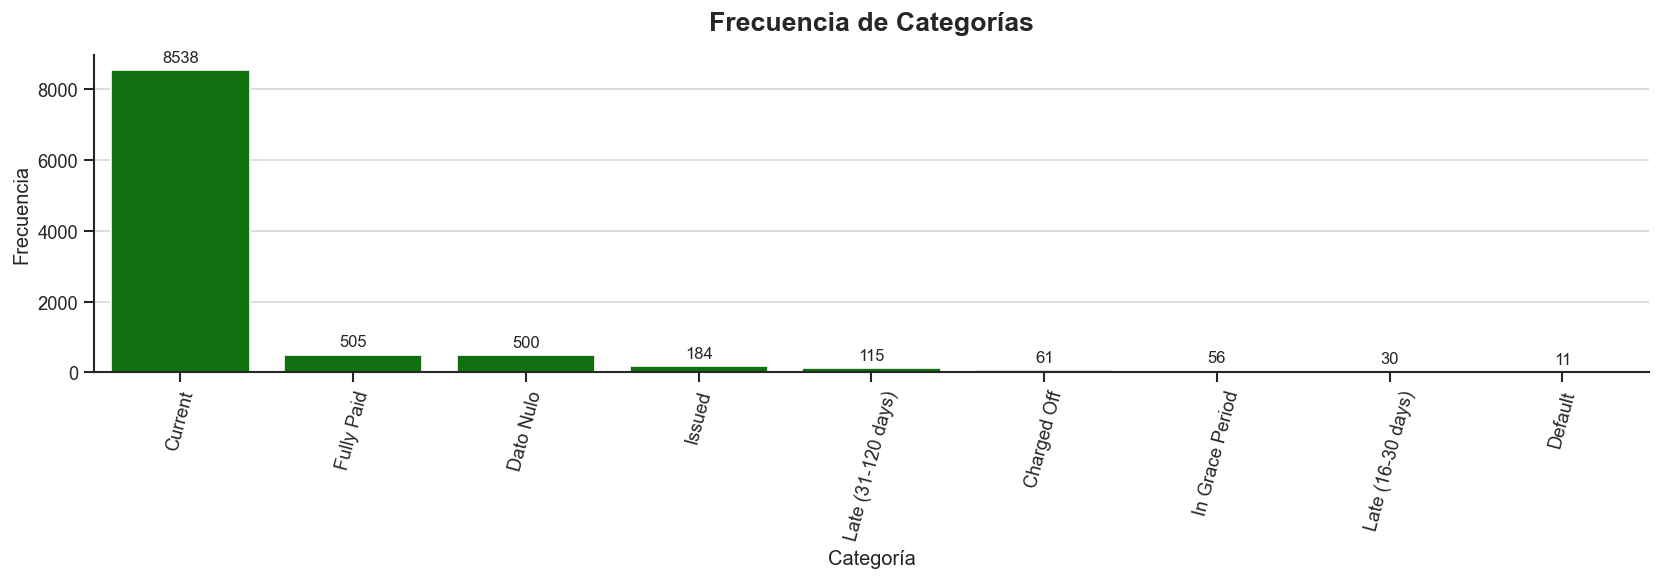

In [292]:
resumen = caracterizar_variable_no_numerica(
    datos=datos_pandas,
    variable=columnas_no_numericas[2]
)
resumen_categorias.append(resumen)

#### **Variable: Grado**

Caracterización de variable: grado
🔹 Calidad de datos
  • Valores ausentes: 515
  • Proporción de valores ausentes: 5.15 %

🔹 Diversidad de valores
  • Valores únicos: 7
  • Proporción de valores únicos: 0.07 %
  • Entropía de Shannon (normalizada): 0.8348
  • Número efectivo de categorías: 5.08

🔹 Medidas de Concentración y Dominancia
  • Moda: C
  • Antimodal: G
  • Frecuencia de la Moda: 2766.0000
  • Proporción de la máxima frecuencia: 27.66 %
  • Frecuencia del Antimodal: 40.0000
  • Proporción de la mínima frecuencia: 0.4 %
  • Índice de dominancia extrema: 69.15
  • Índice de dominancia global: 0.38

🔹 Balance de las categorías
  • Coeficiente de variación de las frecuencias: 79.18 %
     - La distribución presenta un desbalance importante y una o pocas categorías concentran la mayor parte de las observaciones
  • Índice de Simpson: 0.2196
  • Mínimo Teórico del Índice de Simpson: 0.1429
  • Índice Normalizado de Simpson: 8.9488 %
  • Coeficiente de uniformidad: 0.7251
     - Bu

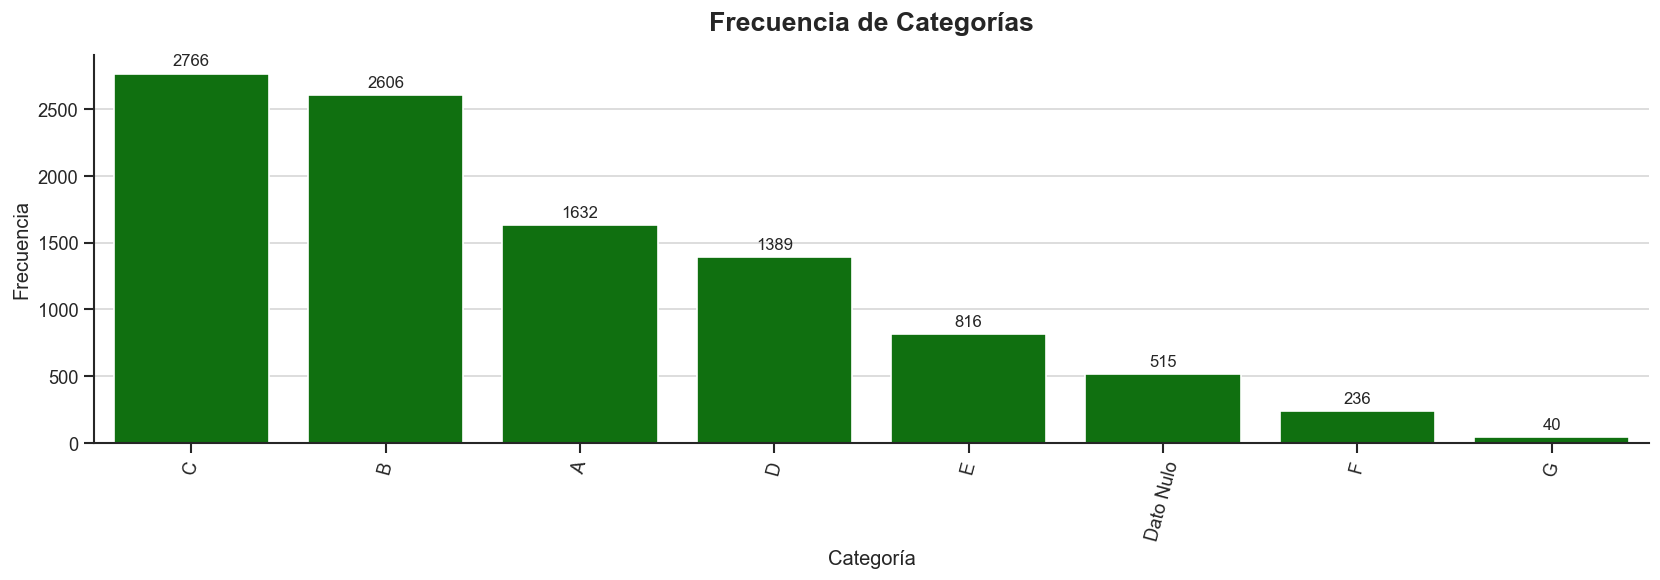

In [293]:
resumen = caracterizar_variable_no_numerica(
    datos=datos_pandas,
    variable=columnas_no_numericas[3]
)
resumen_categorias.append(resumen)

#### **Variable: Sub-Grado**

Caracterización de variable: sub_grado
🔹 Calidad de datos
  • Valores ausentes: 514
  • Proporción de valores ausentes: 5.14 %

🔹 Diversidad de valores
  • Valores únicos: 35
  • Proporción de valores únicos: 0.35 %
  • Entropía de Shannon (normalizada): 0.9045
  • Número efectivo de categorías: 24.93

🔹 Medidas de Concentración y Dominancia
  • Moda: C1
  • Antimodal: G5
  • Frecuencia de la Moda: 629.0000
  • Proporción de la máxima frecuencia: 6.29 %
  • Frecuencia del Antimodal: 2.0000
  • Proporción de la mínima frecuencia: 0.02 %
  • Índice de dominancia extrema: 314.5
  • Índice de dominancia global: 0.07

🔹 Balance de las categorías
  • Coeficiente de variación de las frecuencias: 76.86 %
     - La distribución presenta un desbalance importante y una o pocas categorías concentran la mayor parte de las observaciones
  • Índice de Simpson: 0.045
  • Mínimo Teórico del Índice de Simpson: 0.0286
  • Índice Normalizado de Simpson: 1.6883 %
  • Coeficiente de uniformidad: 0.7122
    

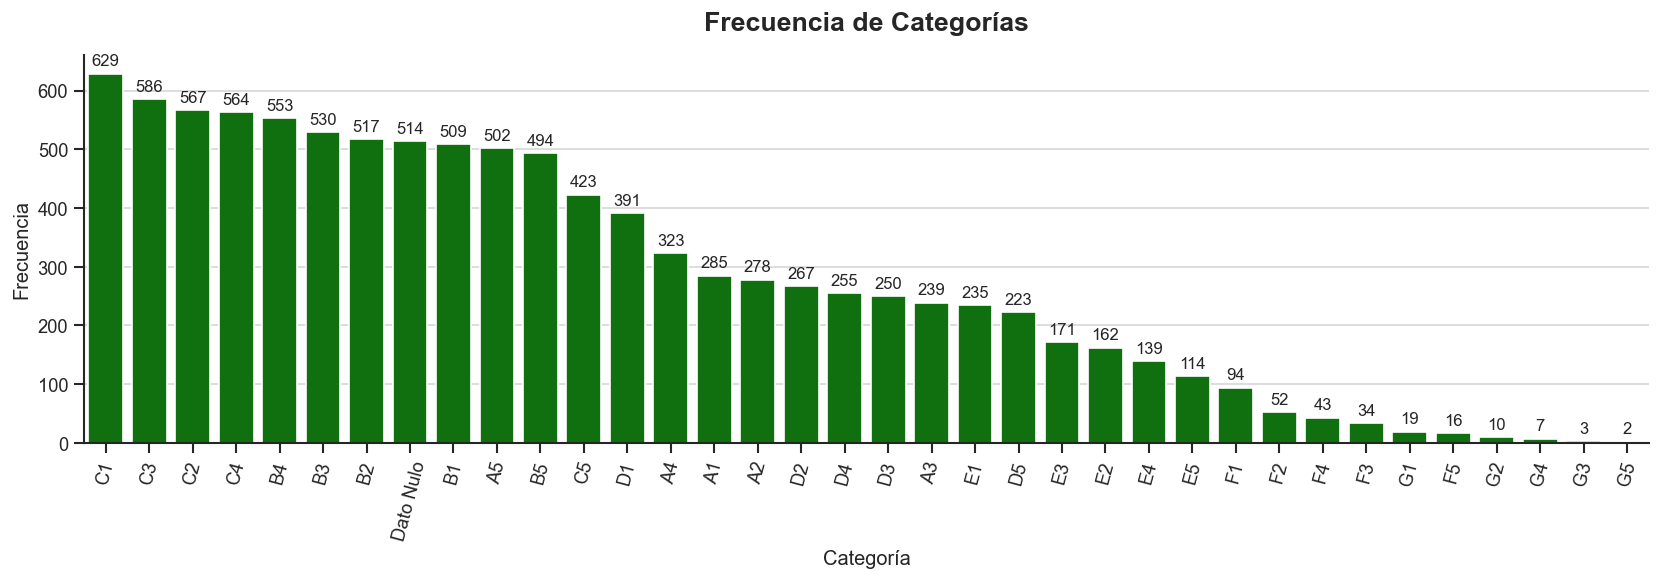

In [294]:
resumen = caracterizar_variable_no_numerica(
    datos=datos_pandas,
    variable=columnas_no_numericas[4]
)
resumen_categorias.append(resumen)

#### **Variable: Estado Verificación**

Caracterización de variable: estado_verificacion
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 3
  • Proporción de valores únicos: 0.03 %
  • Entropía de Shannon (normalizada): 0.9804
  • Número efectivo de categorías: 2.94

🔹 Medidas de Concentración y Dominancia
  • Moda: Source Verified
  • Antimodal: Not Verified
  • Frecuencia de la Moda: 4116.0000
  • Proporción de la máxima frecuencia: 41.16 %
  • Frecuencia del Antimodal: 2673.0000
  • Proporción de la mínima frecuencia: 26.73 %
  • Índice de dominancia extrema: 1.54
  • Índice de dominancia global: 0.7

🔹 Balance de las categorías
  • Coeficiente de variación de las frecuencias: 25.97 %
     - Existe cierto desbalance entre categorías, aunque ninguna domina claramente.
  • Índice de Simpson: 0.3483
  • Mínimo Teórico del Índice de Simpson: 0.3333
  • Índice Normalizado de Simpson: 2.2499 %
  • Coeficiente de uniformidad: 0.9786
     - Distrib

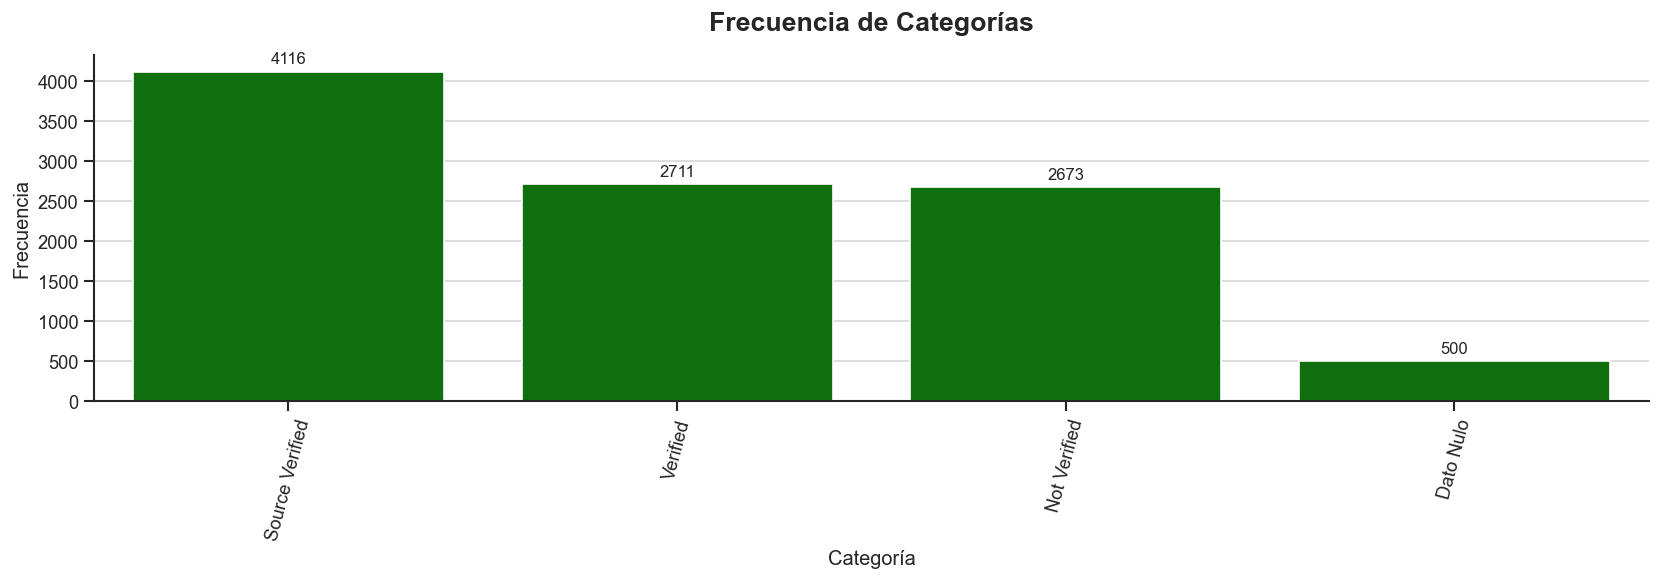

In [295]:
resumen = caracterizar_variable_no_numerica(
    datos=datos_pandas,
    variable=columnas_no_numericas[5]
)
resumen_categorias.append(resumen)

#### **Variable: Estado**

Caracterización de variable: estado
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 49
  • Proporción de valores únicos: 0.49 %
  • Entropía de Shannon (normalizada): 0.8631
  • Número efectivo de categorías: 28.77

🔹 Medidas de Concentración y Dominancia
  • Moda: CA
  • Antimodal: ME
  • Frecuencia de la Moda: 1336.0000
  • Proporción de la máxima frecuencia: 13.36 %
  • Frecuencia del Antimodal: 10.0000
  • Proporción de la mínima frecuencia: 0.1 %
  • Índice de dominancia extrema: 133.6
  • Índice de dominancia global: 0.15

🔹 Balance de las categorías
  • Coeficiente de variación de las frecuencias: 125.72 %
     - La distribución presenta un desbalance importante y una o pocas categorías concentran la mayor parte de las observaciones
  • Índice de Simpson: 0.052
  • Mínimo Teórico del Índice de Simpson: 0.0204
  • Índice Normalizado de Simpson: 3.2258 %
  • Coeficiente de uniformidad: 0.5871
     

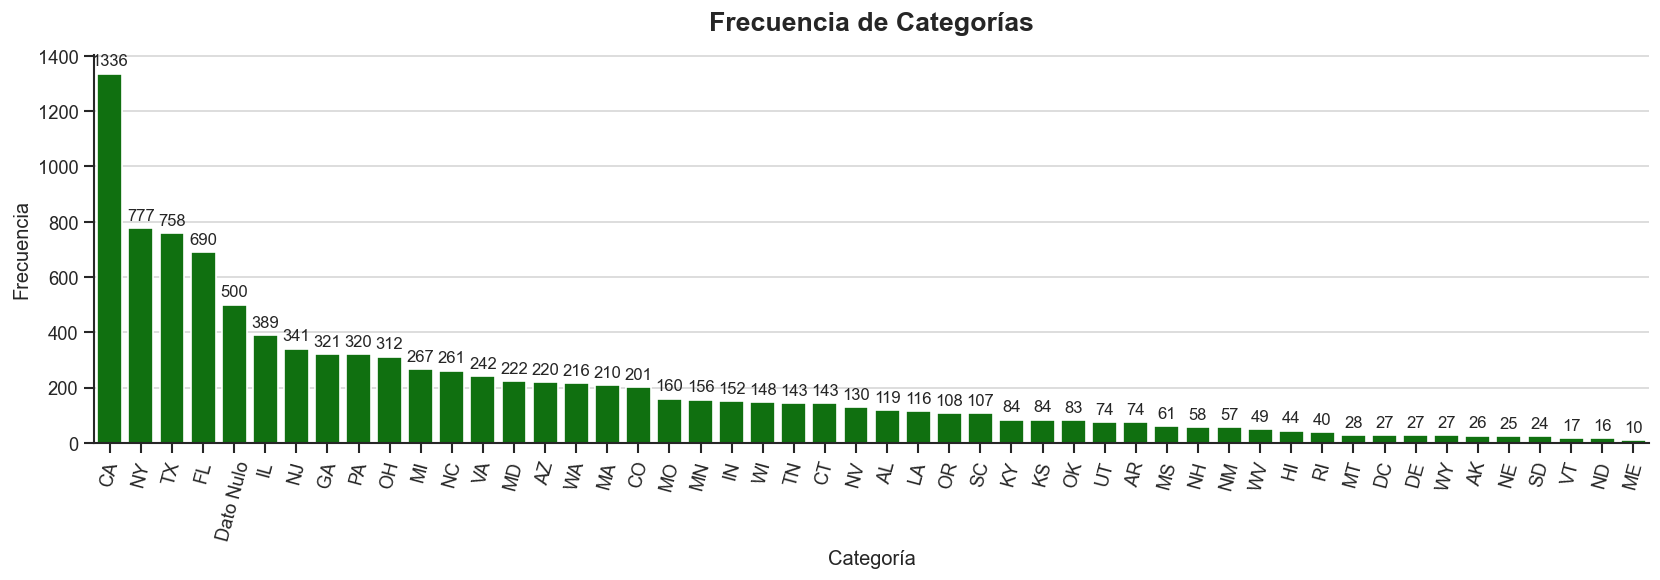

In [296]:
resumen = caracterizar_variable_no_numerica(
    datos=datos_pandas,
    variable=columnas_no_numericas[6]
)
resumen_categorias.append(resumen)

#### **Resumen de Variables Categóricas**

In [ ]:
resumen_categorias_pandas = pd.DataFrame(resumen_variables)
resumen_categorias_pandas.set_index("variable", inplace=True)

resumen_categorias_pandas.to_csv('metricas_variables_numericas.csv')
resumen_categorias_pandas.head()

# Proceso de Imputación
___
___

### Análisis Multivariable

####  **Métricas de Validez de Datos**

### **Observaciones por Variables**

Existen diversas relaciones que pueden establecerse entre los valores contenidos en las variables que conforman la base de datos proporcionada:

* Se analiza la posible correlación entre las variables `loan_amnt` y `funded_amnt`, con el objetivo de evaluar la viabilidad de un proceso de imputación de valores ausentes en ambas columnas, en caso de existir una relación estadísticamente significativa entre ellas.

* Se identifica una relación directa entre la codificación de las variables `sub_grade` y `grade`, lo que permite considerar la posibilidad de realizar procesos de imputación cruzada en aquellos casos en los que se presenten valores faltantes en alguna de estas variables, aprovechando su correspondencia estructural.